### Machine Learning Project Jupyter File

### Submitted by: Deepti Agrawal

In [1]:
## Importing the packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn import metrics
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix,plot_confusion_matrix

from warnings import filterwarnings
filterwarnings("ignore")
import os

In [2]:
## Checking the current working directory
os.getcwd()

'C:\\Users\\deept'

In [3]:
##Changing the Working directory
os.chdir("D:\GL\ML")

# Problem 1

You are hired by one of the leading news channels CNBE who wants to analyze recent elections. This survey was conducted on 1525 voters with 9 variables. You have to build a model, to predict which party a voter will vote for on the basis of the given information, to create an exit poll that will help in predicting overall win and seats covered by a particular party.

### Data Description:

The data consists of survey of 1525 voters based on their age, economic national condition, political knowledge, Blair, Hague, etc. 

### Attribute Information: 
Data Dictionary:

**Data Dictionary**

1. vote: Party choice: Conservative or Labour

2. age: in years

3. economic.cond.national: Assessment of current national economic conditions, 1 to 5.

4. economic.cond.household: Assessment of current household economic conditions, 1 to 5.

5. Blair: Assessment of the Labour leader, 1 to 5.

6. Hague: Assessment of the Conservative leader, 1 to 5.

7. Europe: an 11-point scale that measures respondents' attitudes toward European integration. High scores represent ‘Eurosceptic’ sentiment.

8. political.knowledge: Knowledge of parties' positions on European integration, 0 to 3.

9. gender: female or male.

<div class="alert alert-block alert-info">

### A) Data Ingestion: 

### Q 1.1 Read the dataset. Do the descriptive statistics and do the null value condition check. Write an inference on it. 


In [4]:
# reading the excel file into pandas dataframe
elect_df = pd.read_excel("Election_Data (1).xlsx",sheet_name="Election_Dataset_Two Classes")

In [5]:
#checking the head(top 10 rows) of the data frame
elect_df.head(5)

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


## Basic EDA
* Checking the shape of the data,data type of individual columns
* Check the presence of missing values
* Descriptive stats of numerical columns
* Finding the distribution of numerical columns and the asssociated skeweness and presence of outliers 
* Distribution of categorical columns

In [6]:
## Checking the number of rows and columns
elect_df.shape

(1525, 10)

In [7]:
#checking the data types /information
elect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               1525 non-null   int64 
 1   vote                     1525 non-null   object
 2   age                      1525 non-null   int64 
 3   economic.cond.national   1525 non-null   int64 
 4   economic.cond.household  1525 non-null   int64 
 5   Blair                    1525 non-null   int64 
 6   Hague                    1525 non-null   int64 
 7   Europe                   1525 non-null   int64 
 8   political.knowledge      1525 non-null   int64 
 9   gender                   1525 non-null   object
dtypes: int64(8), object(2)
memory usage: 119.3+ KB


- The data has 1525 instances with 10 attributes with 2 of type object and rest 8 are integer type.

In [8]:
#checking for missing values
elect_df.isnull().sum()

Unnamed: 0                 0
vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

- there are no null values in our dataset

In [9]:
# drop the unnamed: 0  column as it is useless for the model
elect_df = elect_df.drop('Unnamed: 0', axis=1)

In [10]:
# Dataset after dropping unnamed: 0 column
elect_df.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male
3,Labour,24,4,2,2,1,4,0,female
4,Labour,41,2,2,1,1,6,2,male


In [11]:
# Are there any duplicates
dups = elect_df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
elect_df[dups]

Number of duplicate rows = 8


,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
67,Labour,35,4,4,5,2,3,2,male
626,Labour,39,3,4,4,2,5,2,male
870,Labour,38,2,4,2,2,4,3,male
983,Conservative,74,4,3,2,4,8,2,female
1154,Conservative,53,3,4,2,2,6,0,female
1236,Labour,36,3,3,2,2,6,2,female
1244,Labour,29,4,4,4,2,2,2,female
1438,Labour,40,4,3,4,2,2,2,male


- We have found 8 duplicate records which are of no use for our analysis. Therefore, we will delete these 8 records.

In [12]:
# Dropping the Duplicates
print('Before',elect_df.shape)
elect_df.drop_duplicates(inplace=True) 
print('After',elect_df.shape)

Before (1525, 9)
After (1517, 9)


In [13]:
# Checking again if any duolicate record are left or not
dups = elect_df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


In [14]:
# five point summary of the continuous attributes
elect_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1517.0,54.241266,15.701741,24.0,41.0,53.0,67.0,93.0
economic.cond.national,1517.0,3.245221,0.881792,1.0,3.0,3.0,4.0,5.0
economic.cond.household,1517.0,3.137772,0.931069,1.0,3.0,3.0,4.0,5.0
Blair,1517.0,3.335531,1.174772,1.0,2.0,4.0,4.0,5.0
Hague,1517.0,2.749506,1.232479,1.0,2.0,2.0,4.0,5.0
Europe,1517.0,6.740277,3.299043,1.0,4.0,6.0,10.0,11.0
political.knowledge,1517.0,1.540541,1.084417,0.0,0.0,2.0,2.0,3.0


- The mean age of the voters is 54 years and minimum being 24 years.
- 25 % of voters have economic condition national less than or equal to 3
- the economic national condition and economic household condition is almost same on an average.
- 50 % of the voters accessed labour leader Blair as 4 or 5 but the average rating is 3.33
- 25 % of the voters accessed conservative leader Hague as a 4 or 5 but the average rating is 2.74
- 50% voters have a Europe score of 6 or less than 6. This means that we have equal percentage of supporters and oppositions.
- 25% people have no political knowledge

In [15]:
# Checking for zero values in the data
(elect_df == 0).sum(axis=0)

vote                         0
age                          0
economic.cond.national       0
economic.cond.household      0
Blair                        0
Hague                        0
Europe                       0
political.knowledge        454
gender                       0
dtype: int64

- We only have zero values in column named political.knowledge which is okay with us because this column can have values 0, 1,2 and 3 in it.

### unique values for categorical variables

In [16]:
for column in elect_df.columns:
    if elect_df[column].dtype == 'object':
        print(column.upper(),': ',elect_df[column].nunique())
        print(elect_df[column].value_counts().sort_values())
        print('\n')

VOTE :  2
Conservative     460
Labour          1057
Name: vote, dtype: int64


GENDER :  2
male      709
female    808
Name: gender, dtype: int64




- From this we can observe that we have an imbalanced data with 469 voters who have conservative as their party choice and 1057 who have labor as the choice.
- Number of females and males are almost equally distributed

### Inference from basic data analysis

- The data provided was in an excel format which we converted into a pandas dataframe to ease our analysis.
- The data originally had 1525 instances with 10 attributes with 2 of type object and rest 8 are integer type.After which, we have dropped column named Unnamed : 0 as it was irrelevant.Also, we found 8 duplicate records which we have removed from our dataset as they will not add any value to our analysis.Finally, we are left with 1517 observations over 9 attributes.
- We do not have any null values or zero values in our dataset.
- The mean age of the voters is 54 years and minimum being 24 years.
- 25 % of voters have economic condition national less than or equal to 3
- the economic national condition and economic household condition is almost same on an average.
- 50 % of the voters accessed labour leader Blair as 4 or 5 but the average rating is 3.33
- 25 % of the voters accessed conservative leader Hague as a 4 or 5 but the average rating is 2.74
- 50% voters have a Europe score of 6 or less than 6. This means that we have equal percentage of supporters and oppositions.
- 25% people have no political knowledge.
- The two categorical columns are Vote and Gender. There are only 460 voters who prefer conservative and 1057 who have Labor as their party choice.Also, there are 709 male and 808 female voters in our dataset.


### Q 1.2 Perform Univariate and Bivariate Analysis. Do exploratory data analysis. Check for Outliers. (7 Marks)

### Univariate Analysis

#### Plots to see the distribution of the continuous features individually

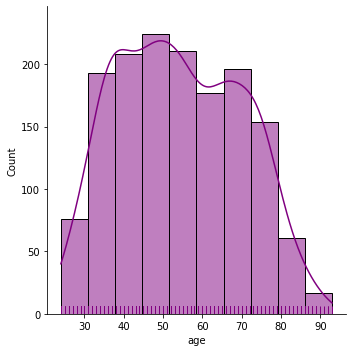

In [17]:
#Plot for age

sns.displot(elect_df['age'], kde =True, rug =True, color ='purple', bins =10)

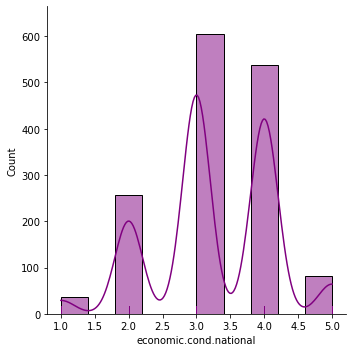

In [18]:
#Plot for economic.cond.national

sns.displot(elect_df['economic.cond.national'], kde =True, rug =True, color ='purple', bins =10)

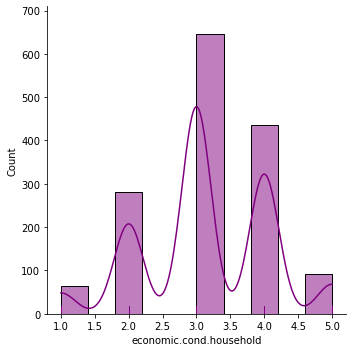

In [19]:
#Plot for economic.cond.household

sns.displot(elect_df['economic.cond.household'], kde =True, rug =True, color ='purple', bins =10)

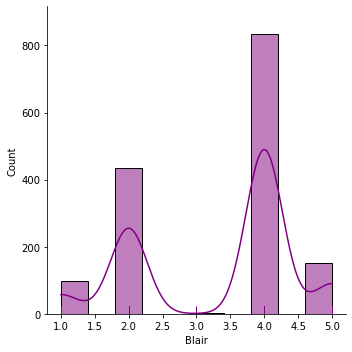

In [20]:
#Plot for Blair

sns.displot(elect_df['Blair'], kde =True, rug =True, color ='purple', bins =10)

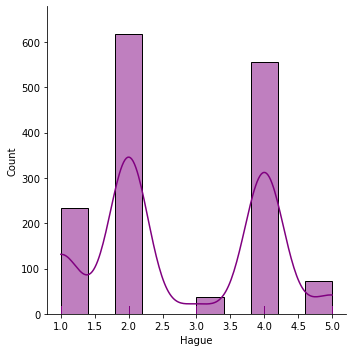

In [21]:
#Plot for Hague

sns.displot(elect_df['Hague'], kde =True, rug =True, color ='purple', bins =10)

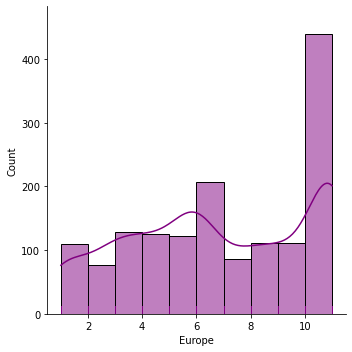

In [22]:
#Plot for Europe

sns.displot(elect_df['Europe'], kde =True, rug =True, color ='purple', bins =10)

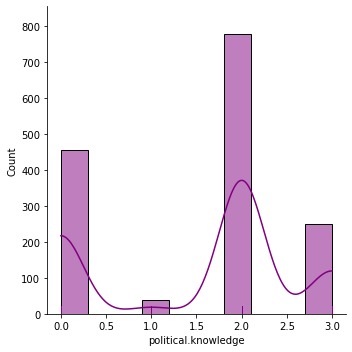

In [23]:
#Plot for political.knowledge

sns.displot(elect_df['political.knowledge'], kde =True, rug =True, color ='purple', bins =10)

### BoxPlots of Individual Attributes and Checking of Outliers

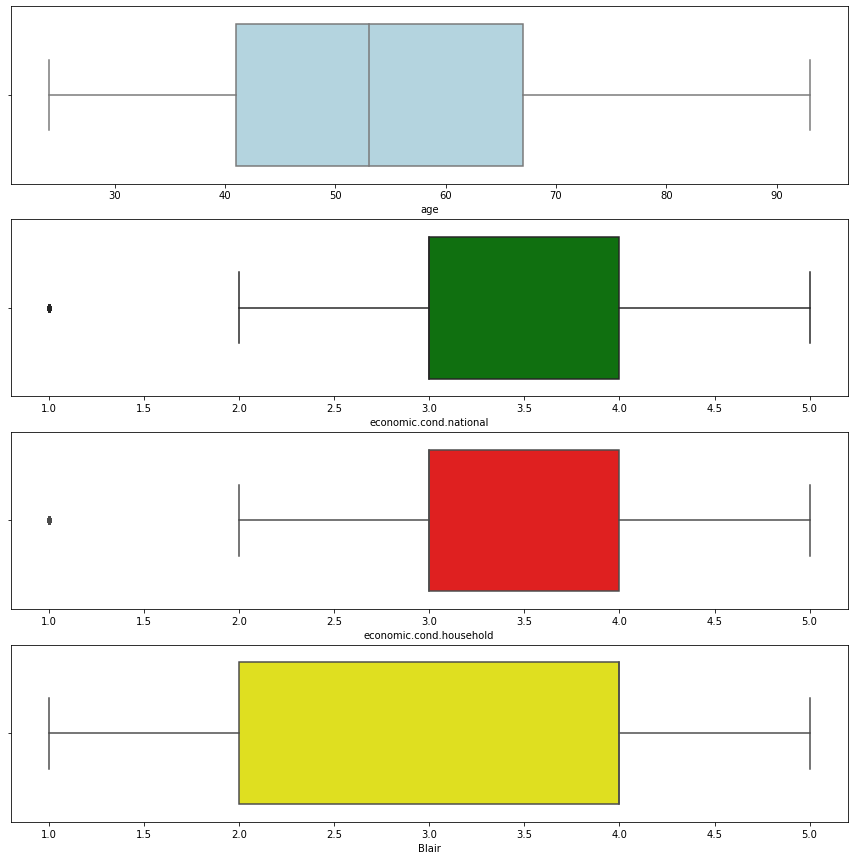

In [24]:
plt.figure(figsize =(15,15))
plt.subplot(4,1,1)
sns.boxplot(x =elect_df['age'] ,color = 'lightblue')

plt.subplot(4,1,2)
sns.boxplot(x =elect_df['economic.cond.national'], color = 'green')

plt.subplot(4,1,3)
sns.boxplot(x =elect_df['economic.cond.household'], color = 'red')

plt.subplot(4,1,4)
sns.boxplot(x =elect_df['Blair'], color = 'yellow')

plt.show()

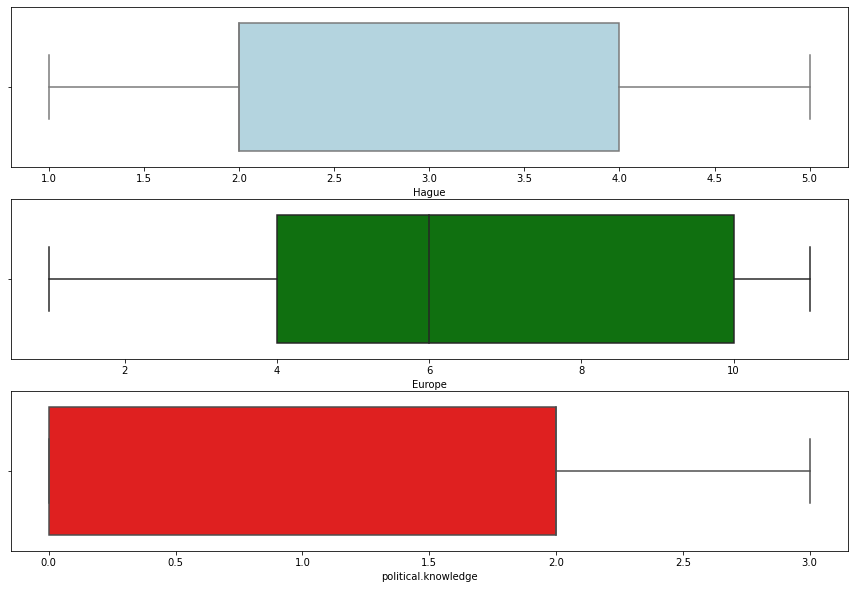

In [25]:
plt.figure(figsize =(15,10))
plt.subplot(3,1,1)
sns.boxplot(x =elect_df['Hague'] ,color = 'lightblue')

plt.subplot(3,1,2)
sns.boxplot(x =elect_df['Europe'], color = 'green')

plt.subplot(3,1,3)
sns.boxplot(x =elect_df['political.knowledge'], color = 'red')


plt.show()

- We can see that only two columns i.e. economic.cond.national and economic.cond.household have outlier in them.Also, both these columns show similar boxplots i.e. similar distribution.
- Age looks almost normally distributed
- Blair and Hague has a wide spread of data in between 2 and 4. Both these columns shows similar distribution in box plot.
- Maximum people have political knowledge graded as equal to or less than 2

#### Treating the outliers.

In [26]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [27]:
## This is a loop to treat outliers for all the non-'object' type varible

for column in elect_df.columns:
     if elect_df[column].dtype != 'object': 
         lr,ur=remove_outlier(elect_df[column])
         elect_df[column]=np.where(elect_df[column]>ur,ur,elect_df[column])
         elect_df[column]=np.where(elect_df[column]<lr,lr,elect_df[column])

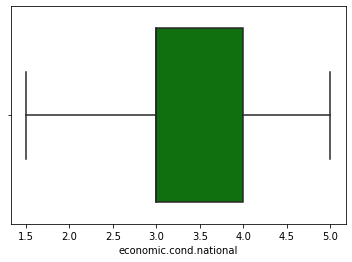

In [28]:
sns.boxplot(x =elect_df['economic.cond.national'], color = 'green')

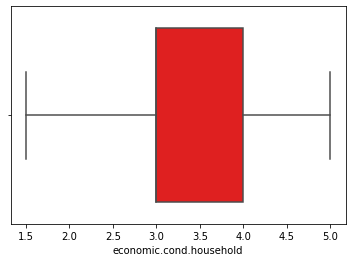

In [29]:
sns.boxplot(x =elect_df['economic.cond.household'], color = 'red')

- The outliers are removed now.

### Measure of Skewness

In [30]:
import scipy.stats as stats

In [31]:
# Measure the skeweness of the required columns
Skewness = pd.DataFrame({'Skewness' : [stats.skew(elect_df['age']),stats.skew(elect_df['economic.cond.national']),stats.skew(elect_df['economic.cond.household']),stats.skew(elect_df['Blair']),stats.skew(elect_df['Hague']),stats.skew(elect_df['Europe']),stats.skew(elect_df['political.knowledge'])]},
                        index=['age','economic.cond.national','economic.cond.household','Blair','Hague','Europe','political.knowledge'])  
Skewness

,Skewness
age,0.139662
economic.cond.national,-0.069877
economic.cond.household,0.091742
Blair,-0.538981
Hague,0.146047
Europe,-0.141751
political.knowledge,-0.422509


- Only age and Hague have positive skewness quoteint i.e they are right skewed.
- Blair has the highest negative skewness.

### Plots to see the distribution of the categorical features individually

- We will plot various count plots to see how the variables has been distributed.

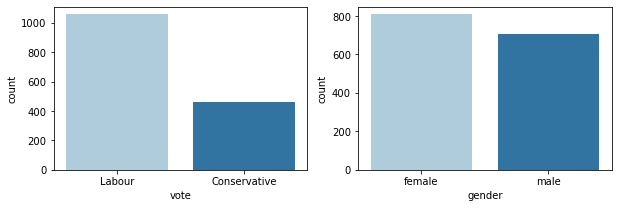

In [32]:
#Countplot for gender and vote

plt.figure(figsize =(10,3))

plt.subplot(1,2,1)
sns.countplot(x='vote', data=elect_df, palette='Paired')

plt.subplot(1,2,2)
sns.countplot(x='gender', data=elect_df, palette='Paired')


plt.show()

- More voters have Labor party choice than Conservative party.
- There are almost equal number of men and women voters in our dataset.

### Bi-variate Analysis

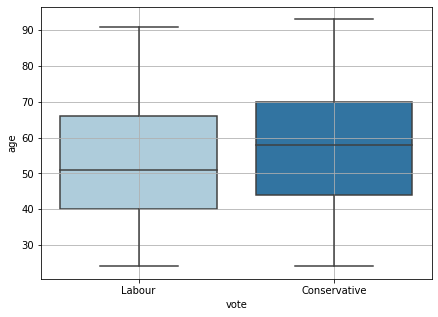

In [33]:
plt.figure(figsize=(7,5))

sns.boxplot(x="vote", y="age", data=elect_df, palette= 'Paired')

plt.grid()
plt.show()

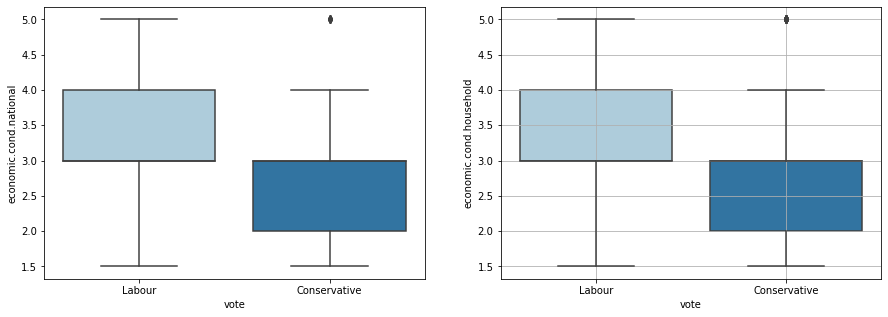

In [34]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x="vote", y="economic.cond.national", data=elect_df, palette= 'Paired')

plt.subplot(1,2,2)
sns.boxplot(x="vote", y="economic.cond.household", data=elect_df, palette= 'Paired')

plt.grid()
plt.show()

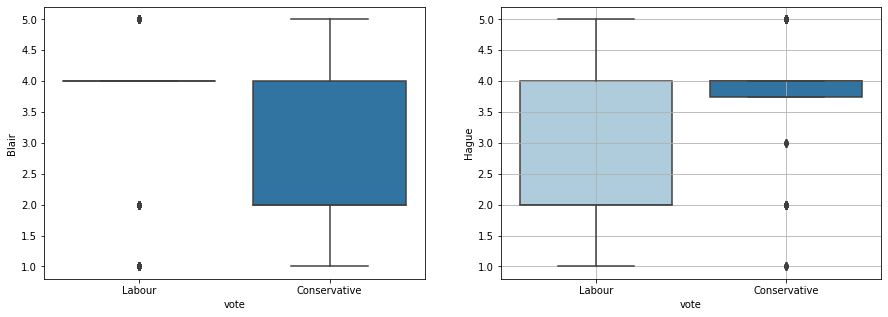

In [35]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x="vote", y="Blair", data=elect_df, palette= 'Paired')

plt.subplot(1,2,2)
sns.boxplot(x="vote", y="Hague", data=elect_df, palette= 'Paired')

plt.grid()
plt.show()

- This shows that Blair and Hague are almost opposite to each other. They seem to be negatively correlated.

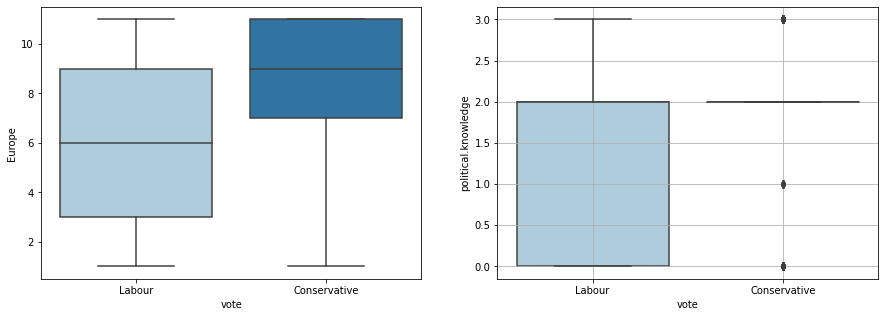

In [36]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x="vote", y="Europe", data=elect_df, palette= 'Paired')

plt.subplot(1,2,2)
sns.boxplot(x="vote", y="political.knowledge", data=elect_df, palette= 'Paired')

plt.grid()
plt.show()

### MultiVariate Analysis

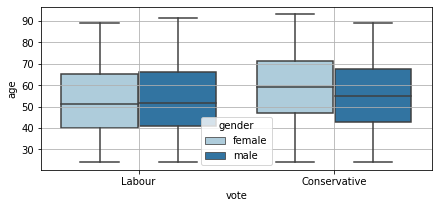

In [37]:
plt.figure(figsize=(7,3))
sns.boxplot(x="vote", y="age", data=elect_df ,hue='gender', palette= 'Paired')
plt.grid()
plt.show()

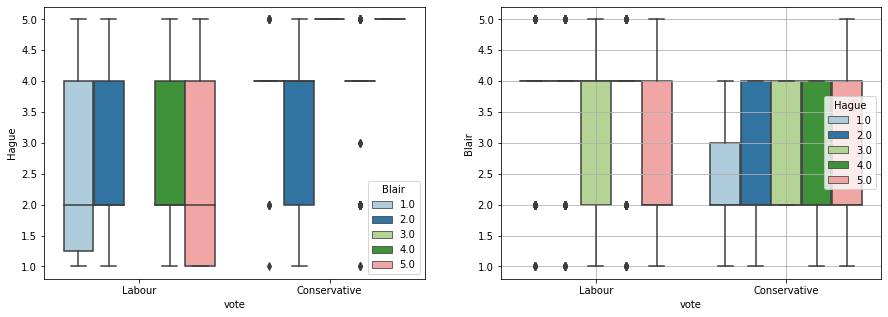

In [38]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x="vote", y="Hague", data=elect_df ,hue='Blair', palette= 'Paired')

plt.subplot(1,2,2)
sns.boxplot(x="vote", y="Blair", data=elect_df ,hue='Hague', palette= 'Paired')

plt.grid()
plt.show()


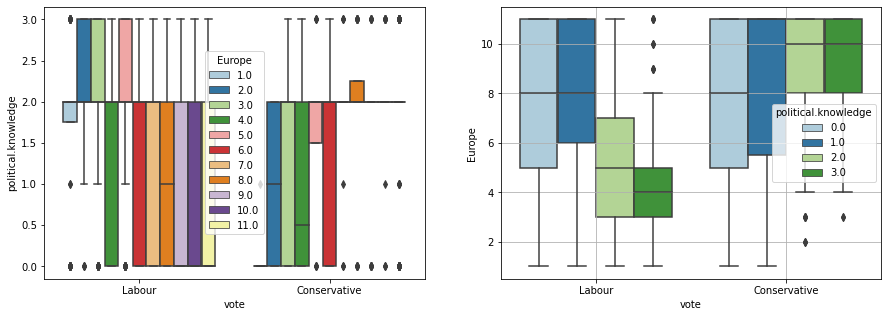

In [39]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x="vote", y="political.knowledge", data=elect_df ,hue='Europe', palette= 'Paired')

plt.subplot(1,2,2)
sns.boxplot(x="vote", y="Europe", data=elect_df ,hue='political.knowledge', palette= 'Paired')

plt.grid()
plt.show()


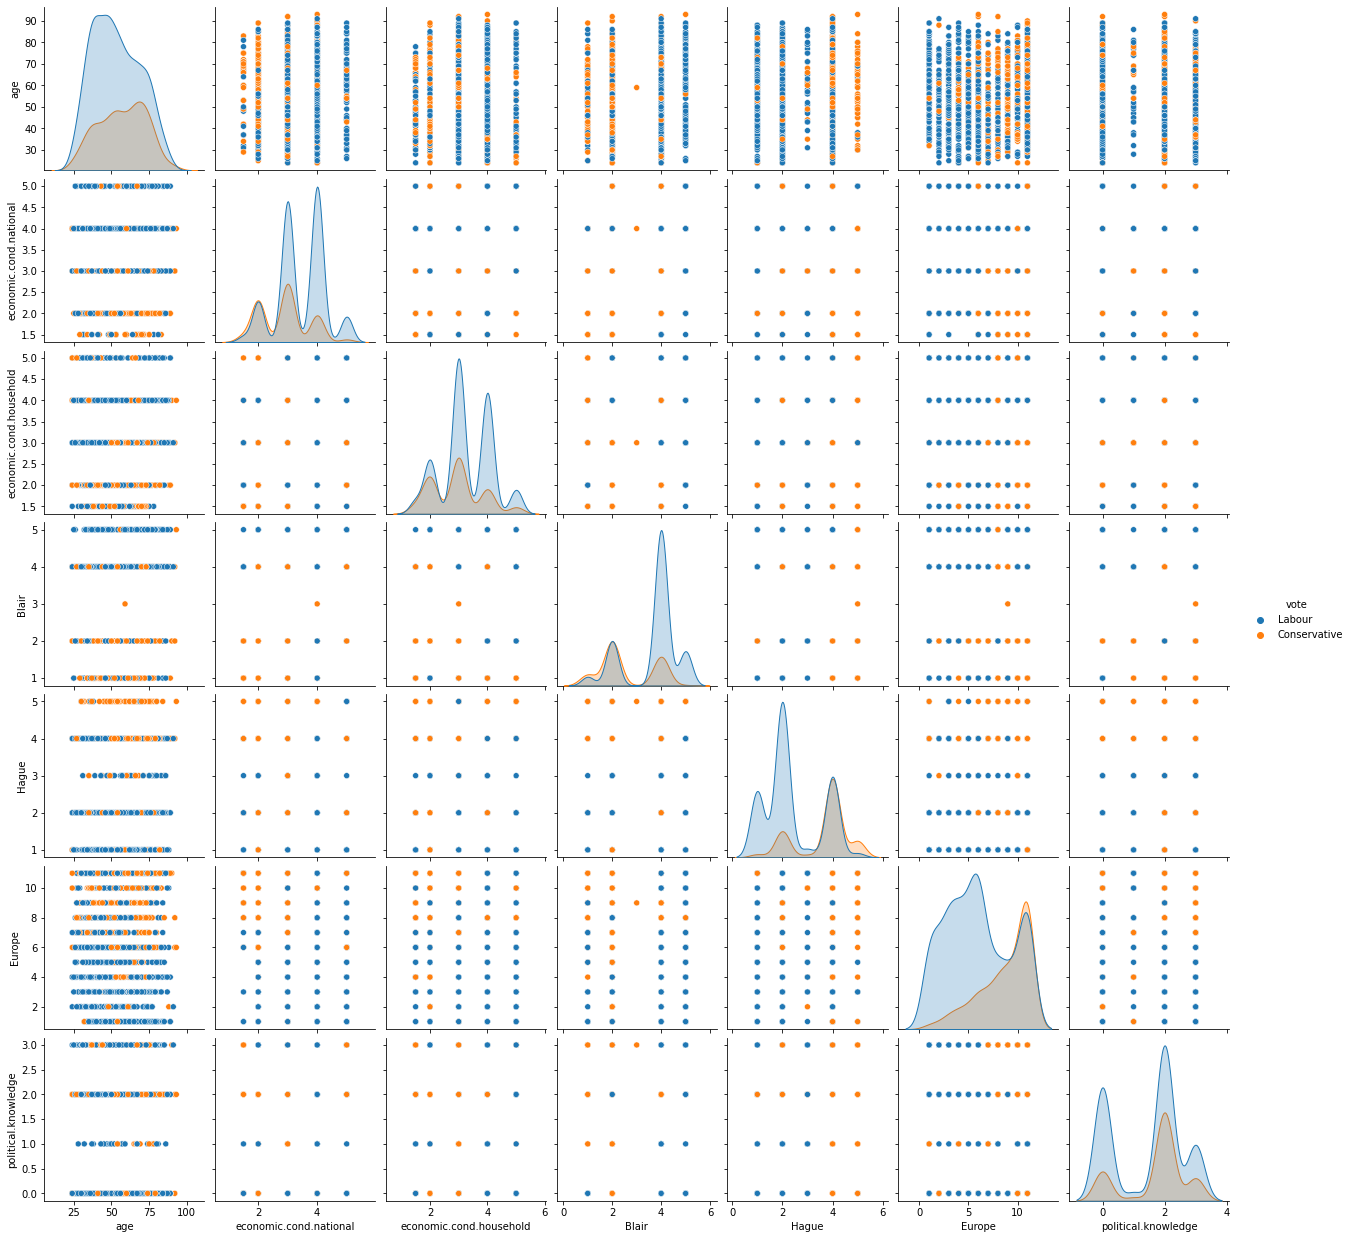

In [40]:
sns.pairplot(elect_df, diag_kind='kde', hue='vote')

- As observed by the pair plot, Europe seems to be a very good predictor of vote.
- Other than that all variables seem to be a good predictor to some extent.

In [41]:
corr = elect_df.corr()
round(corr,2)

,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
age,1.00,0.02,-0.04,0.03,0.03,0.06,-0.05
economic.cond.national,0.02,1.00,0.34,0.32,-0.20,-0.21,-0.03
economic.cond.household,-0.04,0.34,1.00,0.22,-0.10,-0.11,-0.04
Blair,0.03,0.32,0.22,1.00,-0.24,-0.30,-0.02
Hague,0.03,-0.20,-0.10,-0.24,1.00,0.29,-0.03
Europe,0.06,-0.21,-0.11,-0.30,0.29,1.00,-0.15
political.knowledge,-0.05,-0.03,-0.04,-0.02,-0.03,-0.15,1.00


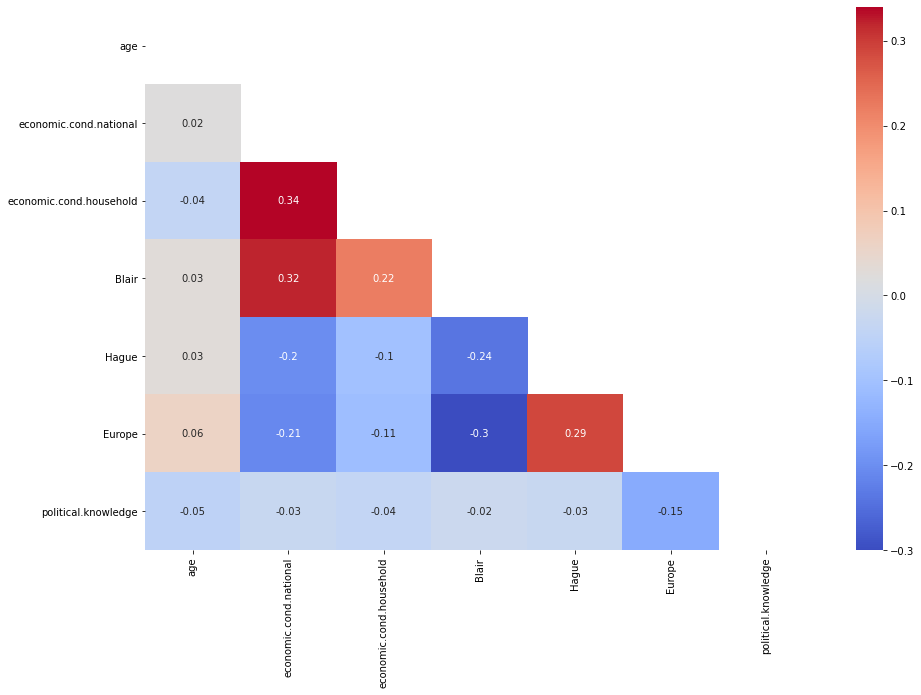

In [42]:
fig_dims = (15,10)
fig = plt.subplots(figsize=fig_dims)
mask = np.triu(np.ones_like(corr, dtype=np.bool)) 
sns.heatmap(round(corr,2), annot=True, mask=mask, cmap ='coolwarm')

- Europe and Blair are highly negatively correlated. Whereas, Europe and Hague are highly positively correlated.
- Hague and Blair are negatively correlated.
- Political knolwedge and Europe also seems negatively correlated.
- Economic national condition is highly negatively correlated to Blair and Economic household condition.
- Blair is highly positively correlated to economic condition household.

In [43]:
elect_df.rename(columns = {'economic.cond.national' : 'economic_cond_national', 'economic.cond.household' : 'economic_cond_household', 'political.knowledge' : 'political_knowledge'}, inplace = True)

In [44]:
elect_df.head()

,vote,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
0,Labour,43.0,3.0,3.0,4.0,1.0,2.0,2.0,female
1,Labour,36.0,4.0,4.0,4.0,4.0,5.0,2.0,male
2,Labour,35.0,4.0,4.0,5.0,2.0,3.0,2.0,male
3,Labour,24.0,4.0,2.0,2.0,1.0,4.0,0.0,female
4,Labour,41.0,2.0,2.0,1.0,1.0,6.0,2.0,male


### Insights from Univariate and Bivariate Analysis

- People who are in favor of European Power i.e. have less Europe value have higher political knowledge and have higher rating of Labor leader i.e. Blair value.
- People who are highly Eurosceptic have higher Hague value.
- People who are highly Eurosceptic have mostly voted for Conservative Party.
- People who have higher economic household condition also have higher Blair score.
- Europe seems to be a very good predictor of vote
- Only age and Hague have positive skewness quotient i.e they are right skewed. Blair has the highest negative skewness.
- We can see that only two columns i.e. economic.cond.national and economic.cond.household have outlier in them. Also, both these columns show similar boxplots i.e. similar distribution.
- Age looks almost normally distributed
- Blair and Hague has a wide spread of data in between 2 and 4. Both these columns shows similar distribution in box plot.
- Maximum people have political knowledge graded as equal to or less than 2
- We have changed few column names for further easy modelling

<div class="alert alert-block alert-info">
    
### B) Data Preparation:

### Q 1.3 Encode the data (having string values) for Modelling. Is Scaling necessary here or not? Data Split: Split the data into train and test (70:30). 

In [45]:
## Converting Object into int
## Decision tree in Python can take only numerical / categorical colums. It cannot take string / object types.
for feature in elect_df.columns: 
    if elect_df[feature].dtype == 'object': 
        print('\n')
        print('feature:',feature)
        print(pd.Categorical(elect_df[feature].unique()))
        print(pd.Categorical(elect_df[feature].unique()).codes)
        elect_df[feature] = pd.Categorical(elect_df[feature]).codes



feature: vote
[Labour, Conservative]
Categories (2, object): [Conservative, Labour]
[1 0]


feature: gender
[female, male]
Categories (2, object): [female, male]
[0 1]


In [46]:
elect_df.head(5)

,vote,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
0,1,43.0,3.0,3.0,4.0,1.0,2.0,2.0,0
1,1,36.0,4.0,4.0,4.0,4.0,5.0,2.0,1
2,1,35.0,4.0,4.0,5.0,2.0,3.0,2.0,1
3,1,24.0,4.0,2.0,2.0,1.0,4.0,0.0,0
4,1,41.0,2.0,2.0,1.0,1.0,6.0,2.0,1


In [47]:
elect_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1517 entries, 0 to 1524
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   vote                     1517 non-null   int8   
 1   age                      1517 non-null   float64
 2   economic_cond_national   1517 non-null   float64
 3   economic_cond_household  1517 non-null   float64
 4   Blair                    1517 non-null   float64
 5   Hague                    1517 non-null   float64
 6   Europe                   1517 non-null   float64
 7   political_knowledge      1517 non-null   float64
 8   gender                   1517 non-null   int8   
dtypes: float64(7), int8(2)
memory usage: 97.8 KB


- Scaling is not necessary here as most of this is ordinal data.
- Ordinal data is a kind of categorical data with a set order or scale to it. For example, ordinal data is said to have been collected when a responder inputs his/her financial happiness level on a scale of 1-10. In ordinal data, there is no standard scale on which the difference in each score is measured.
- Therefore, we will not be performing scaling over here.

#### Checking for Multicollinearity

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [49]:
elect_df.columns

Index(['vote', 'age', 'economic_cond_national', 'economic_cond_household',
       'Blair', 'Hague', 'Europe', 'political_knowledge', 'gender'],
      dtype='object')

In [50]:
X = elect_df[['vote', 'age', 'economic_cond_national', 'economic_cond_household','Blair', 'Hague', 'Europe', 'political_knowledge', 'gender']]
vif = pd.DataFrame()
vif["Variables"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

import statsmodels.formula.api as smf
def vif_cal(input_data):
  x_vars = input_data
  xvars_names = input_data.columns
  for i in range(0,xvars_names.shape[0]):
    y=x_vars[xvars_names[i]]
    x=x_vars[xvars_names.drop(xvars_names[i])]
    rsq = smf.ols(formula ="y~x", data =x_vars).fit().rsquared
    vif = round(1/(1-rsq),2)
    print(xvars_names[i], "VIF = ", vif)

In [51]:
## Ouput using from statsmodels.stats.outliers_influence import variance_inflation_factor
print(vif)

                 Variables        VIF
0                     vote   4.925846
1                      age  10.798051
2   economic_cond_national  18.009370
3  economic_cond_household  14.387975
4                    Blair  11.615947
5                    Hague   6.400508
6                   Europe   5.430496
7      political_knowledge   2.936880
8                   gender   1.933846


- Here we can observe the vif score for all columns except vote, political.knowledge and gender is higher than 5 and but they do not have very high value.
- This shows that our dataset does not have high amount of multicollinearity between its datatypes.

### Train Test Split

In [52]:
# Copy all the predictor variables into X dataframe
X = elect_df.drop('vote', axis=1)

# Copy target into the y dataframe. 
y = elect_df['vote']

In [53]:
X.head()

,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
0,43.0,3.0,3.0,4.0,1.0,2.0,2.0,0
1,36.0,4.0,4.0,4.0,4.0,5.0,2.0,1
2,35.0,4.0,4.0,5.0,2.0,3.0,2.0,1
3,24.0,4.0,2.0,2.0,1.0,4.0,0.0,0
4,41.0,2.0,2.0,1.0,1.0,6.0,2.0,1


In [54]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: vote, dtype: int8

In [55]:
# Split X and y into training and test set in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1)

In [56]:
X_train

,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
991,34.0,2.0,4.0,1.0,4.0,11.0,2.0,0
1274,40.0,4.0,3.0,4.0,4.0,6.0,0.0,1
649,61.0,4.0,3.0,4.0,4.0,7.0,2.0,0
677,47.0,3.0,3.0,4.0,2.0,11.0,0.0,1
538,44.0,5.0,3.0,4.0,2.0,8.0,0.0,1
...,...,...,...,...,...,...,...,...
717,52.0,3.0,3.0,4.0,1.0,6.0,2.0,0
908,43.0,3.0,4.0,2.0,2.0,9.0,2.0,0
1100,74.0,4.0,3.0,5.0,4.0,11.0,0.0,0
236,31.0,3.0,3.0,2.0,3.0,6.0,0.0,0


In [57]:
X_test

,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
504,71.0,3.0,3.0,2.0,2.0,8.0,2.0,0
369,43.0,3.0,2.0,4.0,2.0,8.0,3.0,1
1075,89.0,5.0,5.0,5.0,2.0,1.0,2.0,1
1031,47.0,2.0,3.0,2.0,4.0,8.0,2.0,0
1329,33.0,5.0,4.0,4.0,4.0,8.0,0.0,1
...,...,...,...,...,...,...,...,...
562,37.0,4.0,2.0,4.0,2.0,8.0,1.0,1
928,42.0,2.0,2.0,1.0,2.0,7.0,2.0,0
276,88.0,3.0,3.0,4.0,1.0,6.0,0.0,0
1128,53.0,4.0,3.0,4.0,2.0,10.0,0.0,0


In [58]:
y_train.value_counts(1)

1    0.71065
0    0.28935
Name: vote, dtype: float64

In [59]:
y_test.value_counts(1)

1    0.664474
0    0.335526
Name: vote, dtype: float64

<div class="alert alert-block alert-info">
    
### C) Modeling:

### Q 1.4 Apply Logistic Regression and LDA (linear discriminant analysis). (4 marks)

 ### 1.  Building Logistic Regression Model

In [60]:
# loading library
from sklearn.linear_model import LogisticRegression

In [61]:
# Fit the Logistic Regression model
LRmodel = LogisticRegression()
LRmodel.fit(X_train, y_train)

LogisticRegression()

#### Predicting on Training and Test dataset

In [62]:
ytrain_predictLogit = LRmodel.predict(X_train)
ytest_predictLogit = LRmodel.predict(X_test)

#### Getting the Predicted Classes and Probs

In [63]:
## Getting the probabilities on the test set

ytest_predict_probLogit=LRmodel.predict_proba(X_test)
pd.DataFrame(ytest_predict_probLogit).head()

,0,1
0,0.426582,0.573418
1,0.154442,0.845558
2,0.006791,0.993209
3,0.838994,0.161006
4,0.065152,0.934848


#### Model Accuracy

In [64]:
# Accuracy - Training Data
LRmodel.score(X_train, y_train)

0.8341187558906692

#### Applying GridSearchCV for Logistic Regression

In [65]:
grid={'penalty':['l2','none'],
      'solver':['newton-cg','lbfgs', 'liblinear'],
      'tol':[0.0001,0.00001]}

In [66]:
model = LogisticRegression(max_iter=10000,n_jobs=2)

In [67]:
grid_search = GridSearchCV(estimator = model, param_grid = grid, cv = 3,n_jobs=-1,scoring='f1')
## Scoring - Strategy to evaluate the performance of the cross-validated model on the test set.

In [68]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=10000, n_jobs=2),
             n_jobs=-1,
             param_grid={'penalty': ['l2', 'none'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear'],
                         'tol': [0.0001, 1e-05]},
             scoring='f1')

In [69]:
print(grid_search.best_params_,'\n')
print(grid_search.best_estimator_)

{'penalty': 'l2', 'solver': 'newton-cg', 'tol': 0.0001} 

LogisticRegression(max_iter=10000, n_jobs=2, solver='newton-cg')


In [70]:
best_modelLogit = grid_search.best_estimator_

In [71]:
# Prediction on the training and test set

ytrain_predict = best_modelLogit.predict(X_train)
ytest_predict = best_modelLogit.predict(X_test)

In [72]:
## Getting the probabilities on the test set

ytest_predict_prob=best_modelLogit.predict_proba(X_test)
pd.DataFrame(ytest_predict_prob).head()

,0,1
0,0.425915,0.574085
1,0.153046,0.846954
2,0.006706,0.993294
3,0.839472,0.160528
4,0.065104,0.934896


In [73]:
# Accuracy - Training Data after applying GridSearch
LogReg_train__Accuracy=best_modelLogit.score(X_train, y_train)
LogReg_train__Accuracy

0.8341187558906692

In [74]:
# Accuracy - Test Data after applying GridSearch
LogReg_test__Accuracy=best_modelLogit.score(X_test, y_test)
LogReg_test__Accuracy

0.8289473684210527

- Our model accuracies are same after applying gridSearch also.
- Our train and test accuracy is almost same.

- We will be evaluating our Logistic Regression Model later

 ### 2.  Building LDA Model

In [75]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [76]:
#Build LDA Model
clf = LinearDiscriminantAnalysis()
LDA_model=clf.fit(X_train,y_train)

#### Predicting on Training and Test dataset

In [77]:
# Training Data Class Prediction with a cut-off value of 0.5
LDApred_class_train = LDA_model.predict(X_train)

# Test Data Class Prediction with a cut-off value of 0.5
LDApred_class_test = LDA_model.predict(X_test)

In [78]:
## Getting the probabilities on the train set
pred_class_trainLDA=LDA_model.predict_proba(X_train)
pd.DataFrame(pred_class_trainLDA).head()

,0,1
0,0.950266,0.049734
1,0.077561,0.922439
2,0.305087,0.694913
3,0.080344,0.919656
4,0.011710,0.988290


In [79]:
## Getting the probabilities on the test set

pred_class_testLDA=LDA_model.predict_proba(X_test)
pd.DataFrame(pred_class_testLDA).head()

,0,1
0,0.465970,0.534030
1,0.137501,0.862499
2,0.005997,0.994003
3,0.866101,0.133899
4,0.053663,0.946337


#### Model Accuracy

In [80]:
# Accuracy - Training Data
LDA_train_accuracy=LDA_model.score(X_train, y_train)
LDA_train_accuracy

0.8341187558906692

- Our model is showing 83% accuracy

0.1 

Accuracy Score 0.7615
F1 Score 0.8547 

Confusion Matrix


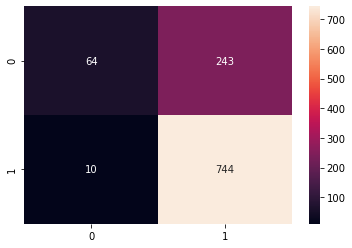

0.2 

Accuracy Score 0.7936
F1 Score 0.8696 

Confusion Matrix


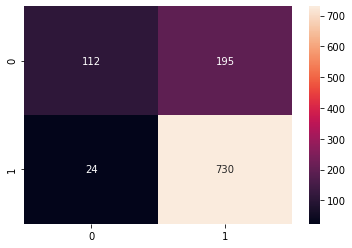

0.3 

Accuracy Score 0.8143
F1 Score 0.8794 

Confusion Matrix


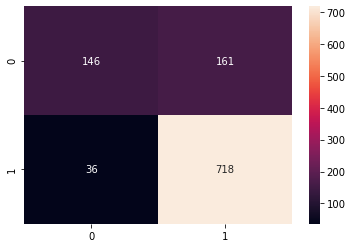

0.4 

Accuracy Score 0.8351
F1 Score 0.89 

Confusion Matrix


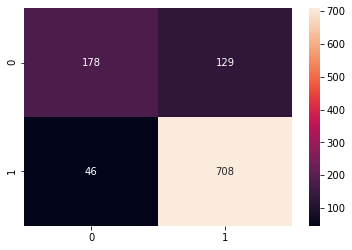

0.5 

Accuracy Score 0.8341
F1 Score 0.8862 

Confusion Matrix


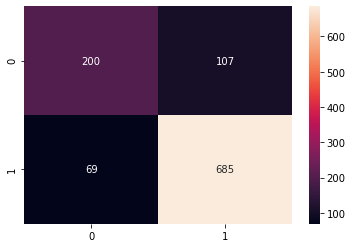

0.6 

Accuracy Score 0.8294
F1 Score 0.8794 

Confusion Matrix


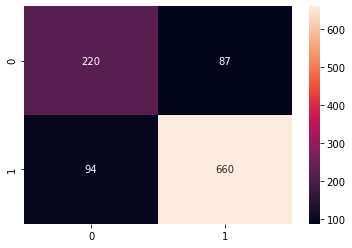

0.7 

Accuracy Score 0.8303
F1 Score 0.875 

Confusion Matrix


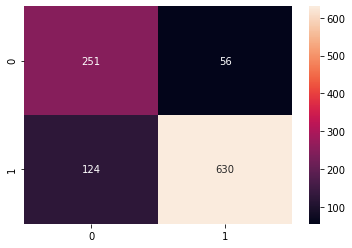

0.8 

Accuracy Score 0.7879
F1 Score 0.8339 

Confusion Matrix


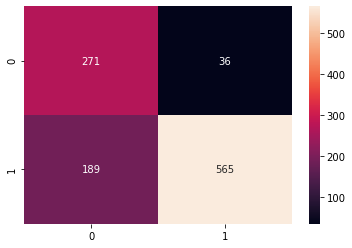

0.9 

Accuracy Score 0.6984
F1 Score 0.739 

Confusion Matrix


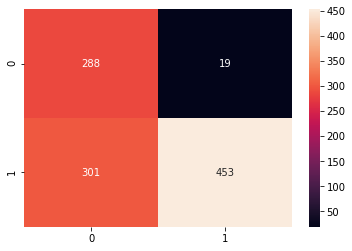

In [81]:
for j in np.arange(0.1,1,0.1):
    custom_prob = j #defining the cut-off value of our choice
    custom_cutoff_data=[]#defining an empty list
    for i in range(0,len(y_train)):#defining a loop for the length of the test data
        if np.array(pred_class_trainLDA[:,1])[i] > custom_prob:#issuing a condition for our probability values to be 
            #greater than the custom cutoff value
            a=1#if the probability values are greater than the custom cutoff then the value should be 1
        else:
            a=0#if the probability values are less than the custom cutoff then the value should be 0
        custom_cutoff_data.append(a)#adding either 1 or 0 based on the condition to the end of the list defined by us
    print(round(j,3),'\n')
    print('Accuracy Score',round(metrics.accuracy_score(y_train,custom_cutoff_data),4))
    print('F1 Score',round(metrics.f1_score(y_train,custom_cutoff_data),4),'\n')
    plt.figure(figsize=(6,4))
    print('Confusion Matrix')
    sns.heatmap(metrics.confusion_matrix(y_train,custom_cutoff_data),annot=True,fmt='.4g'),'\n\n'
    plt.show();

We see that 0.4 and 0.5 gives better accuracy than the rest of the custom cut-off values. We can chhose any of them because both shows a good recall, precision and F1 score. Here, we will take the cut-off as 0.5 to get the optimum 'f1' score which is the default only.

Let us evaluate the predictions of the test data using these cut-off values.

In [82]:
for j in np.arange(0.1,1,0.1):
    custom_prob = j #defining the cut-off value of our choice
    custom_cutoff_train=[]#defining an empty list
    for i in range(0,len(y_train)):#defining a loop for the length of the test data
        if np.array(pred_class_trainLDA[:,1])[i] > custom_prob:#issuing a condition for our probability values to be 
            #greater than the custom cutoff value
            a=1#if the probability values are greater than the custom cutoff then the value should be 1
        else:
            a=0#if the probability values are less than the custom cutoff then the value should be 0
        custom_cutoff_train.append(a)#adding either 1 or 0 based on the condition to the end of the list defined by us
        
    print('Cutoff:', round (j,3),'\t', 'Accuracy:',round(metrics.accuracy_score(y_train,custom_cutoff_train),4),
                                            'recall:',round(metrics.recall_score(y_train,custom_cutoff_train),4),
                                             'precision:',round(metrics.precision_score(y_train,custom_cutoff_train),4),
                                             'F1 Score:',round(metrics.f1_score(y_train,custom_cutoff_train),4)
                )

Cutoff: 0.1 	 Accuracy: 0.7615 recall: 0.9867 precision: 0.7538 F1 Score: 0.8547
Cutoff: 0.2 	 Accuracy: 0.7936 recall: 0.9682 precision: 0.7892 F1 Score: 0.8696
Cutoff: 0.3 	 Accuracy: 0.8143 recall: 0.9523 precision: 0.8168 F1 Score: 0.8794
Cutoff: 0.4 	 Accuracy: 0.8351 recall: 0.939 precision: 0.8459 F1 Score: 0.89
Cutoff: 0.5 	 Accuracy: 0.8341 recall: 0.9085 precision: 0.8649 F1 Score: 0.8862
Cutoff: 0.6 	 Accuracy: 0.8294 recall: 0.8753 precision: 0.8835 F1 Score: 0.8794
Cutoff: 0.7 	 Accuracy: 0.8303 recall: 0.8355 precision: 0.9184 F1 Score: 0.875
Cutoff: 0.8 	 Accuracy: 0.7879 recall: 0.7493 precision: 0.9401 F1 Score: 0.8339
Cutoff: 0.9 	 Accuracy: 0.6984 recall: 0.6008 precision: 0.9597 F1 Score: 0.739


- Since the cutoff score is as usual we will use the previous model only.

### Q 1.5 Apply KNN Model and Naïve Bayes Model. Interpret the results. (4 marks)

### 3.  Building KNN Model

In [83]:
# loading library
from sklearn.neighbors import KNeighborsClassifier

# instantiate learning model (k = 3)
KNN_model=KNeighborsClassifier(n_neighbors = 3,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)


KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [84]:
# predict the response
y_test_predict = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=3 is ", KNN_model.score(X_test, y_test))


Accuracy Score for K=3 is  0.7894736842105263


In [85]:
# instantiate learning model (k = 5)
KNN_model=KNeighborsClassifier(n_neighbors = 5,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=5 is ", KNN_model.score(X_test, y_test))


Accuracy Score for K=5 is  0.8157894736842105


In [86]:
# instantiate learning model (k = 9)
from sklearn.neighbors import KNeighborsClassifier
KNN_model=KNeighborsClassifier(n_neighbors = 9,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=9 is ", KNN_model.score(X_test, y_test))

Accuracy Score for K=9 is  0.8070175438596491


#### Finding out the optimal number of K

We will run the KNN with no of neighbours to be 1,3,5..19 and will find the optimal number of neighbours from the above list using the Mis classification error.


Misclassification error (MCE) = 1 - Test accuracy score. We will calculate MCE for each model with neighbours = 1,3,5...19 and will find out the model with lowest MCE.

In [87]:
# empty list that will hold accuracy scores
ac_scores = []

# perform accuracy metrics for values from 1,3,5....19
for k in range(1,20,2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    # evaluate accuracy
    scores = knn.score(X_test, y_test)
    ac_scores.append(scores)

# changing to misclassification error
MCE = [1 - x for x in ac_scores]
MCE


[0.2192982456140351,
 0.21052631578947367,
 0.1842105263157895,
 0.17543859649122806,
 0.19298245614035092,
 0.19517543859649122,
 0.19736842105263153,
 0.19298245614035092,
 0.20175438596491224,
 0.19517543859649122]

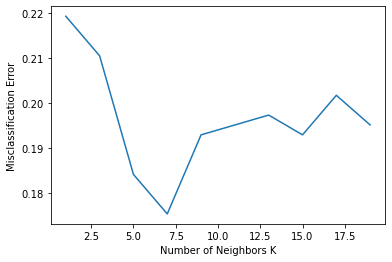

In [88]:
#We will plot misclassification error vs k (with k value on X-axis) using matplotlib.

plt.plot(range(1,20,2), MCE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()

- We can see the misclassification error is lowest for k=7.

In [89]:
# instantiate learning model (k = 7)
from sklearn.neighbors import KNeighborsClassifier
KNN_bestmodel=KNeighborsClassifier(n_neighbors = 7,metric='euclidean')

# fitting the model
KNN_bestmodel.fit(X_train,y_train)

# Training Data Class Prediction 
KNNpred_class_train = KNN_bestmodel.predict(X_train)

# Test Data Class Prediction 
KNNpred_class_test = KNN_bestmodel.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=7 is ", KNN_bestmodel.score(X_test, y_test))

Accuracy Score for K=7 is  0.8245614035087719


### 4.  Building Naive Bayes Model

In [90]:
# loading library
# using Gaussian algorithm from Naive Bayes

from sklearn.naive_bayes import GaussianNB

# instantiate learning model
NB_model = GaussianNB()

# fitting the model
NB_model.fit(X_train, y_train)

GaussianNB()

In [91]:
# Evaluating test model
NB_test_predict = NB_model.predict(X_test)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_test, NB_test_predict)))
print()

Model Accuracy: 0.8224



In [92]:
# Evaluating train model
NB_train_predict = NB_model.predict(X_train)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_train, NB_train_predict)))
print()

Model Accuracy: 0.8341



#### Hyperparameter Tuning on Gaussian Naive Bayes Model

In [93]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [94]:
cv_method = RepeatedStratifiedKFold(n_splits=2,  n_repeats=9, random_state=999)

In [95]:
from sklearn.preprocessing import PowerTransformer

params_NB = {'var_smoothing': np.logspace(0,-9, num=100)}

In [96]:
gs_NB = GridSearchCV(estimator=NB_model, param_grid=params_NB, cv=cv_method,verbose=1,scoring='accuracy')

Data_transformed = PowerTransformer().fit_transform(X_test)

gs_NB.fit(Data_transformed, y_test);

Fitting 18 folds for each of 100 candidates, totalling 1800 fits


In [97]:
results_NB = pd.DataFrame(gs_NB.cv_results_['params'])

In [98]:
results_NB['test_score'] = gs_NB.cv_results_['mean_test_score']

In [99]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [100]:
# predict the target on the test dataset
predict_test = gs_NB.predict(Data_transformed)

# Accuracy Score on test dataset
accuracy_test = accuracy_score(y_test,predict_test)
print('accuracy_score on test dataset : ', accuracy_test)

accuracy_score on test dataset :  0.831140350877193


### Q 1.6 Model Tuning, Bagging (Random Forest should be applied for Bagging), and Boosting. (7 marks)

### 5.  Building Bagging Model using Random Forest

#### Building Random Forest Classifier first)

In [101]:
from sklearn.ensemble import RandomForestClassifier

In [102]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5,6,7],
    'max_features': [2,3,4,5],
    'min_samples_leaf': [15,20],
    'min_samples_split': [50,60,70],
    'n_estimators': [81,101, 201]
}

rfcl = RandomForestClassifier()

grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid, cv = 3)

In [103]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 6, 7], 'max_features': [2, 3, 4, 5],
                         'min_samples_leaf': [15, 20],
                         'min_samples_split': [50, 60, 70],
                         'n_estimators': [81, 101, 201]})

In [104]:
grid_search.best_params_

{'max_depth': 7,
 'max_features': 3,
 'min_samples_leaf': 15,
 'min_samples_split': 50,
 'n_estimators': 81}

In [105]:
best_modelRF = grid_search.best_estimator_

In [106]:
# Evaluating test model
RF_test_predict = best_modelRF.predict(X_test)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_test, RF_test_predict)))
print()

Model Accuracy: 0.8268



In [107]:
# Evaluating train model
RF_train_predict = best_modelRF.predict(X_train)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_train, RF_train_predict)))
print()

Model Accuracy: 0.8549



#### Ensemble Bagging using Random Forest

In [108]:
from sklearn.ensemble import BaggingClassifier

bgcl = BaggingClassifier(base_estimator=best_modelRF, n_estimators=200,random_state=1)

bgcl = bgcl.fit(X_train, y_train)


In [109]:
# Evaluating train model Bagging
BaggingRF_train_predict = bgcl.predict(X_train)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_train, BaggingRF_train_predict)))
print()

Model Accuracy: 0.8379



In [110]:
# Evaluating test model Bagging
BaggingRF_test_predict = bgcl.predict(X_test)

from sklearn import metrics

print("Model Accuracy: {0:.4f}".format(metrics.accuracy_score(y_test, BaggingRF_test_predict)))
print()

Model Accuracy: 0.8158



### 6.  Building Ada Boost Model

In [111]:
from sklearn.ensemble import AdaBoostClassifier

ADB_model = AdaBoostClassifier(n_estimators=200,random_state=1)
ADB_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=200, random_state=1)

#### Predicting on Training and Test dataset

In [112]:
ytrain_predictAda = ADB_model.predict(X_train)
ytest_predictAda = ADB_model.predict(X_test)

In [113]:
## Getting the probabilities on the test set

ytest_predict_probAda=ADB_model.predict_proba(X_test)
pd.DataFrame(ytest_predict_probAda).head()

,0,1
0,0.500906,0.499094
1,0.498493,0.501507
2,0.489948,0.510052
3,0.502467,0.497533
4,0.496605,0.503395


#### Model Accuracy

In [114]:
# Accuracy - Training Data
ADB_model.score(X_train, y_train)

0.8576814326107446

In [115]:
# Accuracy - Test Data
ADB_model.score(X_test, y_test)

0.8114035087719298

### 7.  Building Gradient Boosting Model

In [116]:
from sklearn.ensemble import GradientBoostingClassifier
grad = GradientBoostingClassifier(random_state=1)
grad = grad.fit(X_train, y_train)

#### Predicting on Training and Test dataset

In [117]:
ytrain_predictGrad = grad.predict(X_train)
ytest_predictGrad = grad.predict(X_test)

In [118]:
## Getting the probabilities on the test set

ytest_predict_probGrad=grad.predict_proba(X_test)
pd.DataFrame(ytest_predict_probGrad).head()

,0,1
0,0.690657,0.309343
1,0.236942,0.763058
2,0.001102,0.998898
3,0.840247,0.159753
4,0.111644,0.888356


#### Model Accuracy

In [119]:
# Accuracy - Training Data
grad.score(X_train, y_train)

0.8925541941564562

In [120]:
# Accuracy - Test Data
grad.score(X_test, y_test)

0.8355263157894737

### Q 1.7 Performance Metrics: Check the performance of Predictions on Train and Test sets using Accuracy, Confusion Matrix, Plot ROC curve and get ROC_AUC score for each model. Final Model: Compare the models and write inference which model is best/optimized. (7 marks)

### 1. Performance Matrix of Logistic Regression Model

              precision    recall  f1-score   support

           0       0.75      0.64      0.69       307
           1       0.86      0.91      0.89       754

    accuracy                           0.83      1061
   macro avg       0.81      0.78      0.79      1061
weighted avg       0.83      0.83      0.83      1061
 



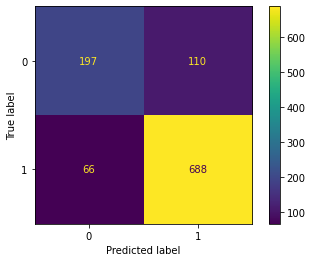

In [121]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(best_modelLogit,X_train,y_train)
print(classification_report(y_train, ytrain_predict),'\n');

In [122]:
Logreg_metrics=classification_report(y_train, ytrain_predict,output_dict=True)
df=pd.DataFrame(Logreg_metrics).transpose()
Logreg_train_precision=round(df.loc["1"][0],2)
Logreg_train_recall=round(df.loc["1"][1],2)
Logreg_train_f1=round(df.loc["1"][2],2)
print ('Logreg_train_precision ',Logreg_train_precision)
print ('Logreg_train_recall ',Logreg_train_recall)
print ('Logreg_train_f1 ',Logreg_train_f1)

Logreg_train_precision  0.86
Logreg_train_recall  0.91
Logreg_train_f1  0.89


              precision    recall  f1-score   support

           0       0.76      0.73      0.74       153
           1       0.86      0.88      0.87       303

    accuracy                           0.83       456
   macro avg       0.81      0.80      0.81       456
weighted avg       0.83      0.83      0.83       456
 



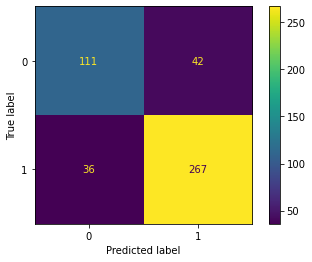

In [123]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(best_modelLogit,X_test,y_test)
print(classification_report(y_test, ytest_predict),'\n');

In [124]:
Logreg_metrics=classification_report(y_test, ytest_predict,output_dict=True)
df=pd.DataFrame(Logreg_metrics).transpose()
Logreg_test_precision=round(df.loc["1"][0],2)
Logreg_test_recall=round(df.loc["1"][1],2)
Logreg_test_f1=round(df.loc["1"][2],2)
print ('Logreg_test_precision ',Logreg_test_precision)
print ('Logreg_test_recall ',Logreg_test_recall)
print ('Logreg_test_f1 ',Logreg_test_f1)

Logreg_test_precision  0.86
Logreg_test_recall  0.88
Logreg_test_f1  0.87


#### Getting the equation

In [125]:
import statsmodels.formula.api as sm

In [126]:
A1 = 'vote ~age+economic_cond_national+economic_cond_household+Blair+Hague+Europe+political_knowledge+gender'

In [127]:
model_1 = sm.logit(formula =A1, data =elect_df).fit()
model_1.summary()

Optimization terminated successfully.
         Current function value: 0.378974
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   vote   No. Observations:                 1517
Model:                          Logit   Df Residuals:                     1508
Method:                           MLE   Df Model:                            8
Date:                Sun, 20 Jun 2021   Pseudo R-squ.:                  0.3824
Time:                        12:30:26   Log-Likelihood:                -574.90
converged:                       True   LL-Null:                       -930.80
Covariance Type:            nonrobust   LLR p-value:                2.077e-148
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   2.9240      0.546      5.351      0.000       1.853       3.995
age                        -0.0187      0.005     -3.906      0.000      -0.028      -0.009
economic_cond_national      0.4567      0.098      4.675      0.000       0.265       0.648
economic_cond_household     0.0782      0.091      0.856      0.392      -0.101       0.257
Blair                       0.6196      0.066      9.356      0.000       0.490       0.749
Hague                      -0.8411      0.066    -12.652      0.000      -0.971      -0.711
Europe                     -0.2147      0.025     -8.541      0.000      -0.264      -0.165
political_knowledge        -0.4072      0.071     -5.697      0.000      -0.547      -0.267
gender                      0.0983      0.151      0.650      0.516      -0.198       0.395
===========================================================================================
"""

In [128]:
# Our model equation
for i,j in np.array(model_1.params.reset_index()):
    print('({}) * {} +'.format(round(j,2),i),end=' ')

(2.92) * Intercept + (-0.02) * age + (0.46) * economic_cond_national + (0.08) * economic_cond_household + (0.62) * Blair + (-0.84) * Hague + (-0.21) * Europe + (-0.41) * political_knowledge + (0.1) * gender + 

In [129]:
# Accuracy - Training Data
best_modelLogit.score(X_train, y_train)

0.8341187558906692

#### AUC and ROC for the training data

Area under Curve is 0.8904215519401413


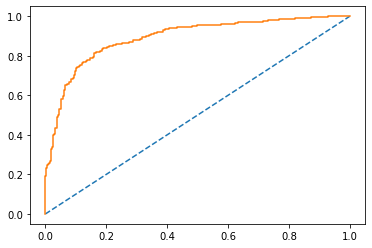

In [130]:
# predict probabilities
probs = best_modelLogit.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
Logreg_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', Logreg_train_auc)
# calculate roc curve
Logit_train_fpr, Logit_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(Logit_train_fpr, Logit_train_tpr);

In [131]:
# Accuracy - Test Data
LogReg_test_Accuracy=best_modelLogit.score(X_test, y_test)
LogReg_test_Accuracy

0.8289473684210527

#### AUC and ROC for the test data

Area under Curve is 0.8831294894195302


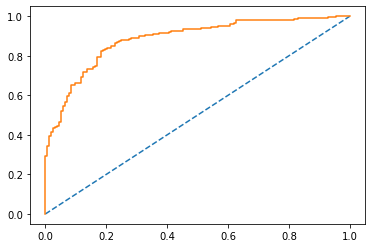

In [132]:
# predict probabilities
probs = best_modelLogit.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
Logreg_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', Logreg_test_auc)
# calculate roc curve
Logit_test_fpr, Logit_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(Logit_test_fpr, Logit_test_tpr);

#### Does my model work?.. Can it predict?

In [133]:
elect_df.head()

,vote,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
0,1,43.0,3.0,3.0,4.0,1.0,2.0,2.0,0
1,1,36.0,4.0,4.0,4.0,4.0,5.0,2.0,1
2,1,35.0,4.0,4.0,5.0,2.0,3.0,2.0,1
3,1,24.0,4.0,2.0,2.0,1.0,4.0,0.0,0
4,1,41.0,2.0,2.0,1.0,1.0,6.0,2.0,1


In [134]:
m1 =elect_df[2:50]
m1

,vote,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
2,1,35.0,4.0,4.0,5.0,2.0,3.0,2.0,1
3,1,24.0,4.0,2.0,2.0,1.0,4.0,0.0,0
4,1,41.0,2.0,2.0,1.0,1.0,6.0,2.0,1
5,1,47.0,3.0,4.0,4.0,4.0,4.0,2.0,1
6,1,57.0,2.0,2.0,4.0,4.0,11.0,2.0,1
7,1,77.0,3.0,4.0,4.0,1.0,1.0,0.0,1
8,1,39.0,3.0,3.0,4.0,4.0,11.0,0.0,0
9,1,70.0,3.0,2.0,5.0,1.0,11.0,2.0,1
10,1,39.0,3.0,3.0,1.0,2.0,7.0,0.0,0
11,1,66.0,4.0,3.0,4.0,4.0,9.0,2.0,1


In [135]:
m2 =m1.drop('vote', axis=1)
m3 = m1['vote']

In [136]:
best_modelLogit.fit(m2,m3)
m4= best_modelLogit.predict(m2)
print(m4)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 1 1 1 0 1 1 1 1]


- If we are taking lesser samples our model is not detecting because of the imbalance of data.

### Insights from our Logistic Regression Model

#### TRAINING DATA
- Accuracy : 83.41%
- AUC : 89.04%
- Precision : 86%
- Recall : 91%
- F1 score : 89%


#### TEST DATA
- Accuracy : 82.89%
- AUC : 88.31%
- Precision : 86%
- Recall : 88%
- F1 score : 87%



### 2. Performance Matrix of LDA Model

              precision    recall  f1-score   support

           0       0.74      0.65      0.69       307
           1       0.86      0.91      0.89       754

    accuracy                           0.83      1061
   macro avg       0.80      0.78      0.79      1061
weighted avg       0.83      0.83      0.83      1061
 



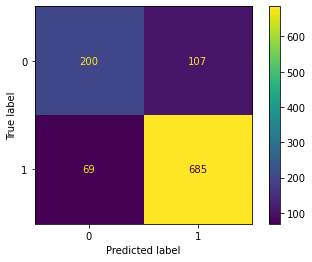

In [137]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(LDA_model,X_train,y_train)
print(classification_report(y_train, LDApred_class_train),'\n');

In [138]:
LDA_metrics=classification_report(y_train, LDApred_class_train,output_dict=True)
df=pd.DataFrame(LDA_metrics).transpose()
LDA_train_precision=round(df.loc["1"][0],2)
LDA_train_recall=round(df.loc["1"][1],2)
LDA_train_f1=round(df.loc["1"][2],2)
print ('LDA_train_precision ',LDA_train_precision)
print ('LDA_train_recall ',LDA_train_recall)
print ('LDA_train_f1 ',LDA_train_f1)

LDA_train_precision  0.86
LDA_train_recall  0.91
LDA_train_f1  0.89


              precision    recall  f1-score   support

           0       0.76      0.73      0.74       153
           1       0.86      0.88      0.87       303

    accuracy                           0.83       456
   macro avg       0.81      0.80      0.81       456
weighted avg       0.83      0.83      0.83       456
 



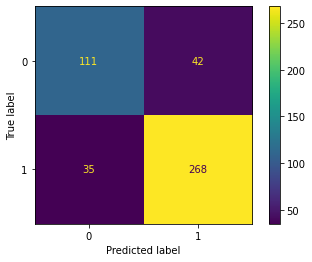

In [139]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(LDA_model,X_test,y_test)
print(classification_report(y_test, LDApred_class_test),'\n');

In [140]:
LDA_metrics=classification_report(y_test, LDApred_class_test,output_dict=True)
df=pd.DataFrame(LDA_metrics).transpose()
LDA_test_precision=round(df.loc["1"][0],2)
LDA_test_recall=round(df.loc["1"][1],2)
LDA_test_f1=round(df.loc["1"][2],2)
print ('LDA_test_precision ',LDA_test_precision)
print ('LDA_test_recall ',LDA_test_recall)
print ('LDA_test_f1 ',LDA_test_f1)

LDA_test_precision  0.86
LDA_test_recall  0.88
LDA_test_f1  0.87


In [141]:
# Accuracy - Training Data
LDA_model.score(X_train, y_train)

0.8341187558906692

#### AUC and ROC for the training data

Area under Curve is 0.889942024728052


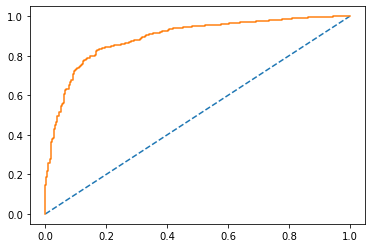

In [142]:
# predict probabilities
probs = LDA_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
LDA_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', LDA_train_auc)
# calculate roc curve
LDA_train_fpr, LDA_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(LDA_train_fpr, LDA_train_tpr);

In [143]:
# Accuracy - Test Data
LDA_test_Accuracy=LDA_model.score(X_test, y_test)
LDA_test_Accuracy

0.831140350877193

#### AUC and ROC for the test data

Area under Curve is 0.8875299294635347


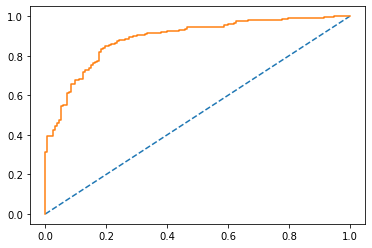

In [144]:
# predict probabilities
probs = LDA_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
LDA_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', LDA_test_auc)
# calculate roc curve
LDA_test_fpr, LDA_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(LDA_test_fpr, LDA_test_tpr);

#### Does my model work?.. Can it predict?

In [145]:
m1

,vote,age,economic_cond_national,economic_cond_household,Blair,Hague,Europe,political_knowledge,gender
2,1,35.0,4.0,4.0,5.0,2.0,3.0,2.0,1
3,1,24.0,4.0,2.0,2.0,1.0,4.0,0.0,0
4,1,41.0,2.0,2.0,1.0,1.0,6.0,2.0,1
5,1,47.0,3.0,4.0,4.0,4.0,4.0,2.0,1
6,1,57.0,2.0,2.0,4.0,4.0,11.0,2.0,1
7,1,77.0,3.0,4.0,4.0,1.0,1.0,0.0,1
8,1,39.0,3.0,3.0,4.0,4.0,11.0,0.0,0
9,1,70.0,3.0,2.0,5.0,1.0,11.0,2.0,1
10,1,39.0,3.0,3.0,1.0,2.0,7.0,0.0,0
11,1,66.0,4.0,3.0,4.0,4.0,9.0,2.0,1


In [146]:
LDA_model.fit(m2,m3)
m4= LDA_model.predict(m2)
print(m4)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 1 1 1 0 1 1 1 1]


### Insights from our LDA Model

#### TRAINING DATA
- Accuracy : 83.41%
- AUC : 88.89%
- Precision : 86%
- Recall : 91%
- F1 score : 89%

#### TEST DATA
- Accuracy : 83.11%
- AUC : 88.75%
- Precision : 86%
- Recall : 88%
- F1 score : 87%


### 3. Performance Matrix of KNN Model

              precision    recall  f1-score   support

           0       0.78      0.66      0.72       307
           1       0.87      0.93      0.90       754

    accuracy                           0.85      1061
   macro avg       0.83      0.79      0.81      1061
weighted avg       0.84      0.85      0.84      1061
 



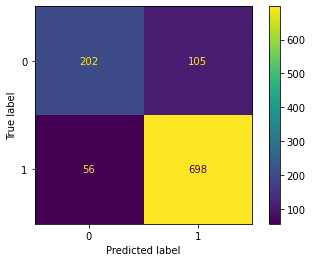

In [147]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(KNN_bestmodel,X_train,y_train)
print(classification_report(y_train, KNNpred_class_train),'\n');

In [148]:
KNN_metrics=classification_report(y_train, KNNpred_class_train,output_dict=True)
df=pd.DataFrame(KNN_metrics).transpose()
KNN_train_precision=round(df.loc["1"][0],2)
KNN_train_recall=round(df.loc["1"][1],2)
KNN_train_f1=round(df.loc["1"][2],2)
print ('KNN_train_precision ',KNN_train_precision)
print ('KNN_train_recall ',KNN_train_recall)
print ('KNN_train_f1 ',KNN_train_f1)

KNN_train_precision  0.87
KNN_train_recall  0.93
KNN_train_f1  0.9


              precision    recall  f1-score   support

           0       0.79      0.65      0.71       153
           1       0.84      0.91      0.87       303

    accuracy                           0.82       456
   macro avg       0.81      0.78      0.79       456
weighted avg       0.82      0.82      0.82       456
 



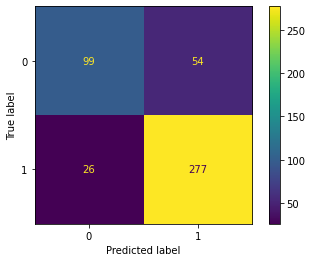

In [149]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(KNN_bestmodel,X_test,y_test)
print(classification_report(y_test, KNNpred_class_test),'\n');

In [150]:
KNN_metrics=classification_report(y_test, KNNpred_class_test,output_dict=True)
df=pd.DataFrame(KNN_metrics).transpose()
KNN_test_precision=round(df.loc["1"][0],2)
KNN_test_recall=round(df.loc["1"][1],2)
KNN_test_f1=round(df.loc["1"][2],2)
print ('KNN_test_precision ',KNN_test_precision)
print ('KNN_test_recall ',KNN_test_recall)
print ('KNN_test_f1 ',KNN_test_f1)

KNN_test_precision  0.84
KNN_test_recall  0.91
KNN_test_f1  0.87


In [189]:
# Accuracy - Training Data
KNN_train_Accuracy=KNN_bestmodel.score(X_train, y_train)
KNN_train_Accuracy

0.8482563619227145

In [152]:
# Accuracy - Test Data
KNN_test_Accuracy=KNN_bestmodel.score(X_test, y_test)
KNN_test_Accuracy

0.8245614035087719

#### AUC and ROC for the training data

Area under Curve is 0.9182298101763451


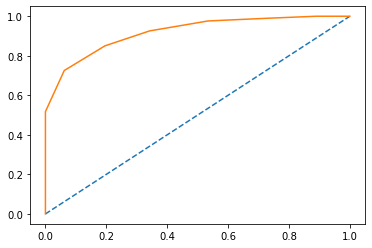

In [153]:
# predict probabilities
probs = KNN_bestmodel.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
KNN_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', KNN_train_auc)
# calculate roc curve
KNN_train_fpr, KNN_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(KNN_train_fpr, KNN_train_tpr);

#### AUC and ROC for the test data

Area under Curve is 0.8611920015530965


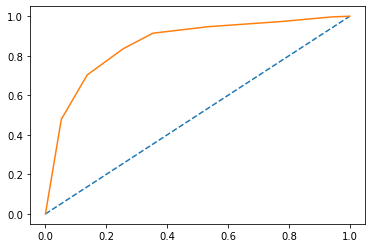

In [154]:
# predict probabilities
probs = KNN_bestmodel.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
KNN_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', KNN_test_auc)
# calculate roc curve
KNN_test_fpr, KNN_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(KNN_test_fpr, KNN_test_tpr);

### Insights from our KNN Model

#### TRAINING DATA
- Accuracy : 84.82%
- AUC : 91.82%
- Precision : 87%
- Recall : 93%
- F1 score : 90%

#### TEST DATA
- Accuracy : 82.45%
- AUC : 86.11%
- Precision : 84%
- Recall : 91%
- F1 score : 87%

#### OVERALL SUMMARY
-

### 4. Performance Matrix of Naive Bayes(Gaussian) Model

              precision    recall  f1-score   support

           0       0.72      0.69      0.71       307
           1       0.88      0.89      0.88       754

    accuracy                           0.83      1061
   macro avg       0.80      0.79      0.80      1061
weighted avg       0.83      0.83      0.83      1061
 



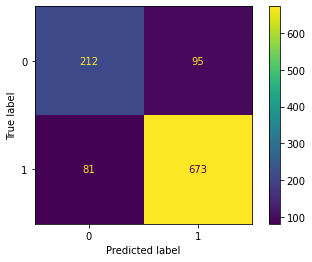

In [155]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(NB_model,X_train,y_train)
print(classification_report(y_train, NB_train_predict),'\n');

In [156]:
NB_metrics=classification_report(y_train, NB_train_predict,output_dict=True)
df=pd.DataFrame(NB_metrics).transpose()
NB_train_precision=round(df.loc["1"][0],2)
NB_train_recall=round(df.loc["1"][1],2)
NB_train_f1=round(df.loc["1"][2],2)
print ('NB_train_precision ',NB_train_precision)
print ('NB_train_recall ',NB_train_recall)
print ('NB_train_f1 ',NB_train_f1)

NB_train_precision  0.88
NB_train_recall  0.89
NB_train_f1  0.88


              precision    recall  f1-score   support

           0       0.74      0.73      0.73       153
           1       0.87      0.87      0.87       303

    accuracy                           0.82       456
   macro avg       0.80      0.80      0.80       456
weighted avg       0.82      0.82      0.82       456
 



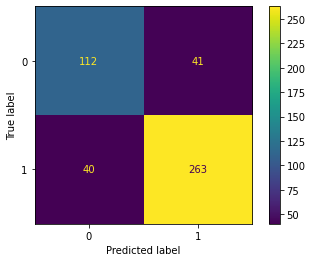

In [157]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(NB_model,X_test,y_test)
print(classification_report(y_test, NB_test_predict),'\n');

In [158]:
NB_metrics=classification_report(y_test, NB_test_predict,output_dict=True)
df=pd.DataFrame(NB_metrics).transpose()
NB_test_precision=round(df.loc["1"][0],2)
NB_test_recall=round(df.loc["1"][1],2)
NB_test_f1=round(df.loc["1"][2],2)
print ('NB_test_precision ',NB_test_precision)
print ('NB_test_recall ',NB_test_recall)
print ('NB_test_f1 ',NB_test_f1)

NB_test_precision  0.87
NB_test_recall  0.87
NB_test_f1  0.87


In [192]:
# Accuracy - Training Data
NB_train_Accuracy=NB_model.score(X_train, y_train)
NB_train_Accuracy

0.8341187558906692

In [160]:
# Accuracy - Test Data
NB_test_Accuracy=NB_model.score(X_test, y_test)
NB_test_Accuracy

0.8223684210526315

#### Performance Matrix after Hyperparameters on test set

              precision    recall  f1-score   support

           0       0.74      0.76      0.75       153
           1       0.88      0.87      0.87       303

    accuracy                           0.83       456
   macro avg       0.81      0.81      0.81       456
weighted avg       0.83      0.83      0.83       456
 



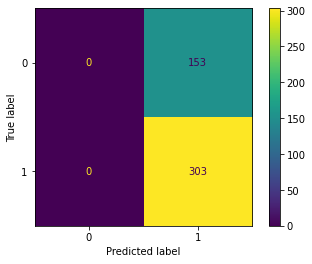

In [161]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(gs_NB,X_test,y_test)
print(classification_report(y_test, predict_test),'\n');

Area under Curve is 0.8890304910185849


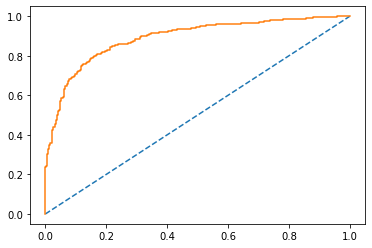

In [162]:
# predict probabilities
probs = NB_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
NB_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', NB_train_auc)
# calculate roc curve
NB_train_fpr, NB_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(NB_train_fpr, NB_train_tpr);

Area under Curve is 0.876442546215406


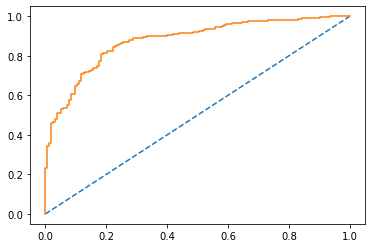

In [163]:
# predict probabilities
probs = NB_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
NB_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', NB_test_auc)
# calculate roc curve
NB_test_fpr, NB_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(NB_test_fpr, NB_test_tpr);

### Insights from our Naive Bayes Model

#### TRAINING DATA
- Accuracy : 83.41%
- AUC : 88.9%
- Precision : 88%
- Recall : 89%
- F1 score : 88%

#### TEST DATA
- Accuracy : 82.23%
- AUC : 87.64%
- Precision : 87%
- Recall : 87%
- F1 score : 87%

#### OVERALL SUMMARY
-

### 5. Performance Matrix of Bagging Model using Random Forest Model

              precision    recall  f1-score   support

           0       0.80      0.59      0.68       307
           1       0.85      0.94      0.89       754

    accuracy                           0.84      1061
   macro avg       0.82      0.76      0.78      1061
weighted avg       0.83      0.84      0.83      1061
 



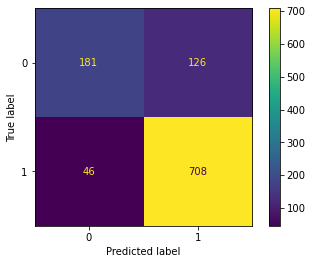

In [164]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(bgcl,X_train,y_train)
print(classification_report(y_train, BaggingRF_train_predict),'\n');

In [165]:
Bag_metrics=classification_report(y_train, BaggingRF_train_predict,output_dict=True)
df=pd.DataFrame(Bag_metrics).transpose()
Bag_train_precision=round(df.loc["1"][0],2)
Bag_train_recall=round(df.loc["1"][1],2)
Bag_train_f1=round(df.loc["1"][2],2)
print ('Bag_train_precision ',Bag_train_precision)
print ('Bag_train_recall ',Bag_train_recall)
print ('Bag_train_f1 ',Bag_train_f1)

Bag_train_precision  0.85
Bag_train_recall  0.94
Bag_train_f1  0.89


              precision    recall  f1-score   support

           0       0.80      0.60      0.69       153
           1       0.82      0.92      0.87       303

    accuracy                           0.82       456
   macro avg       0.81      0.76      0.78       456
weighted avg       0.81      0.82      0.81       456
 



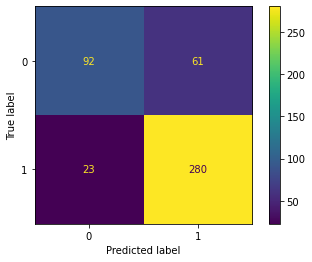

In [166]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(bgcl,X_test,y_test)
print(classification_report(y_test, BaggingRF_test_predict),'\n');

In [167]:
Bag_metrics=classification_report(y_test, BaggingRF_test_predict,output_dict=True)
df=pd.DataFrame(Bag_metrics).transpose()
Bag_test_precision=round(df.loc["1"][0],2)
Bag_test_recall=round(df.loc["1"][1],2)
Bag_test_f1=round(df.loc["1"][2],2)
print ('Bag_test_precision ',Bag_test_precision)
print ('Bag_test_recall ',Bag_test_recall)
print ('Bag_test_f1 ',Bag_test_f1)

Bag_test_precision  0.82
Bag_test_recall  0.92
Bag_test_f1  0.87


In [194]:
# Accuracy - Training Data
Bag_train_Accuracy=bgcl.score(X_train, y_train)
Bag_train_Accuracy

0.8378887841658812

In [169]:
# Accuracy - Test Data
Bag_test_Accuracy=bgcl.score(X_test, y_test)
Bag_test_Accuracy

0.8157894736842105

Area under Curve is 0.9050428118438902


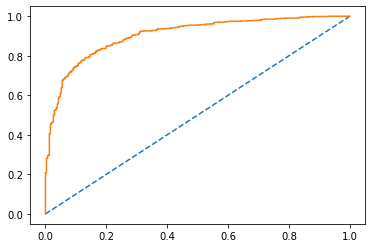

In [170]:
# predict probabilities
probs = bgcl.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
Bag_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', Bag_train_auc)
# calculate roc curve
Bag_train_fpr, Bag_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(Bag_train_fpr, Bag_train_tpr);

Area under Curve is 0.8866670980823572


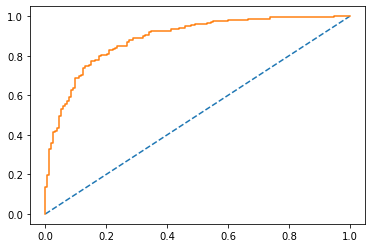

In [171]:
# predict probabilities
probs = bgcl.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
Bag_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', Bag_test_auc)
# calculate roc curve
Bag_test_fpr, Bag_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(Bag_test_fpr, Bag_test_tpr);

### Insights from our Bagging Model using Random Forest

#### TRAINING DATA
- Accuracy : 83.88%
- AUC : 90.51%
- Precision : 85%
- Recall : 94%
- F1 score : 89%

#### TEST DATA
- Accuracy : 81.57%
- AUC : 88.69%
- Precision : 82%
- Recall : 92%
- F1 score : 87%

#### OVERALL SUMMARY
-

### 6. Performance Matrix of AdaBoost Model

              precision    recall  f1-score   support

           0       0.78      0.71      0.74       307
           1       0.89      0.92      0.90       754

    accuracy                           0.86      1061
   macro avg       0.83      0.81      0.82      1061
weighted avg       0.85      0.86      0.86      1061
 



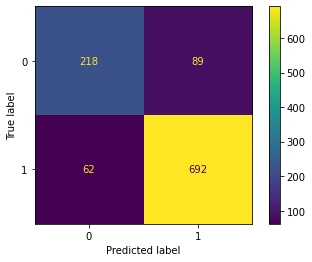

In [172]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(ADB_model,X_train,y_train)
print(classification_report(y_train, ytrain_predictAda),'\n');

In [173]:
Ada_metrics=classification_report(y_train, ytrain_predictAda,output_dict=True)
df=pd.DataFrame(Ada_metrics).transpose()
Ada_train_precision=round(df.loc["1"][0],2)
Ada_train_recall=round(df.loc["1"][1],2)
Ada_train_f1=round(df.loc["1"][2],2)
print ('Ada_train_precision ',Ada_train_precision)
print ('Ada_train_recall ',Ada_train_recall)
print ('Ada_train_f1 ',Ada_train_f1)

Ada_train_precision  0.89
Ada_train_recall  0.92
Ada_train_f1  0.9


              precision    recall  f1-score   support

           0       0.75      0.66      0.70       153
           1       0.84      0.89      0.86       303

    accuracy                           0.81       456
   macro avg       0.79      0.77      0.78       456
weighted avg       0.81      0.81      0.81       456
 



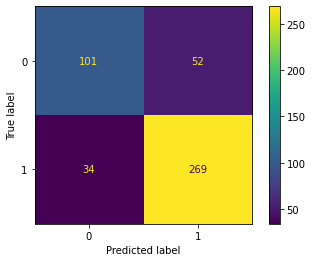

In [174]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(ADB_model,X_test,y_test)
print(classification_report(y_test, ytest_predictAda),'\n');

In [175]:
Ada_metrics=classification_report(y_test, ytest_predictAda,output_dict=True)
df=pd.DataFrame(Ada_metrics).transpose()
Ada_test_precision=round(df.loc["1"][0],2)
Ada_test_recall=round(df.loc["1"][1],2)
Ada_test_f1=round(df.loc["1"][2],2)
print ('Ada_test_precision ',Ada_test_precision)
print ('Ada_test_recall ',Ada_test_recall)
print ('Ada_test_f1 ',Ada_test_f1)

Ada_test_precision  0.84
Ada_test_recall  0.89
Ada_test_f1  0.86


In [196]:
# Accuracy - Training Data
Ada_train_Accuracy=ADB_model.score(X_train, y_train)
Ada_train_Accuracy

0.8576814326107446

In [177]:
# Accuracy - Test Data
Ada_test_Accuracy=ADB_model.score(X_test, y_test)
Ada_test_Accuracy

0.8114035087719298

Area under Curve is 0.9181434088768696


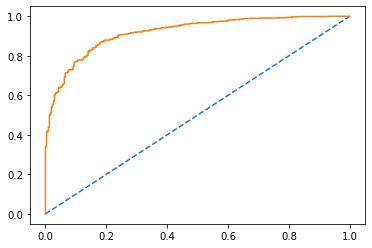

In [178]:
# predict probabilities
probs = ADB_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
Ada_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', Ada_train_auc)
# calculate roc curve
Ada_train_fpr, Ada_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(Ada_train_fpr, Ada_train_tpr);

Area under Curve is 0.8771759528894066


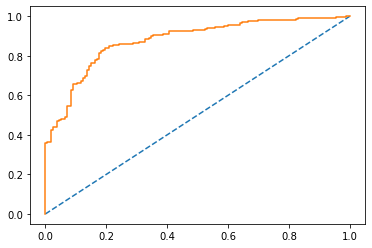

In [179]:
# predict probabilities
probs = ADB_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
Ada_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', Ada_test_auc)
# calculate roc curve
Ada_test_fpr, Ada_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(Ada_test_fpr, Ada_test_tpr);

### Insights from our Ada Boost Model

#### TRAINING DATA
- Accuracy : 85.76%
- AUC : 91.81%
- Precision : 89%
- Recall : 92%
- F1 score : 90%

#### TEST DATA
- Accuracy : 81.14%
- AUC : 87.71%
- Precision : 84%
- Recall : 89%
- F1 score : 86%

#### OVERALL SUMMARY
-

### 7. Performance Matrix of Gradient Boost Model

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       307
           1       0.91      0.94      0.93       754

    accuracy                           0.89      1061
   macro avg       0.88      0.86      0.87      1061
weighted avg       0.89      0.89      0.89      1061
 



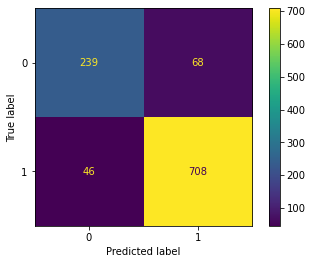

In [180]:
## Confusion matrix and Classification Report on the training data

plot_confusion_matrix(grad,X_train,y_train)
print(classification_report(y_train, ytrain_predictGrad),'\n');

In [181]:
grad_metrics=classification_report(y_train, ytrain_predictGrad,output_dict=True)
df=pd.DataFrame(grad_metrics).transpose()
grad_train_precision=round(df.loc["1"][0],2)
grad_train_recall=round(df.loc["1"][1],2)
grad_train_f1=round(df.loc["1"][2],2)
print ('grad_train_precision ',grad_train_precision)
print ('grad_train_recall ',grad_train_recall)
print ('grad_train_f1 ',grad_train_f1)

grad_train_precision  0.91
grad_train_recall  0.94
grad_train_f1  0.93


              precision    recall  f1-score   support

           0       0.80      0.69      0.74       153
           1       0.85      0.91      0.88       303

    accuracy                           0.84       456
   macro avg       0.82      0.80      0.81       456
weighted avg       0.83      0.84      0.83       456
 



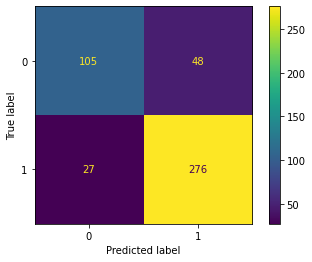

In [182]:
## Confusion matrix and Classification Report on the test data

plot_confusion_matrix(grad,X_test,y_test)
print(classification_report(y_test, ytest_predictGrad),'\n');

In [183]:
grad_metrics=classification_report(y_test, ytest_predictGrad,output_dict=True)
df=pd.DataFrame(grad_metrics).transpose()
grad_test_precision=round(df.loc["1"][0],2)
grad_test_recall=round(df.loc["1"][1],2)
grad_test_f1=round(df.loc["1"][2],2)
print ('grad_test_precision ',grad_test_precision)
print ('grad_test_recall ',grad_test_recall)
print ('grad_test_f1 ',grad_test_f1)

grad_test_precision  0.85
grad_test_recall  0.91
grad_test_f1  0.88


In [197]:
# Accuracy - Training Data
grad_train_Accuracy=grad.score(X_train, y_train)
grad_train_Accuracy

0.8925541941564562

In [185]:
# Accuracy - Test Data
grad_test_Accuracy=grad.score(X_test, y_test)
grad_test_Accuracy

0.8355263157894737

Area under Curve is 0.951155185373988


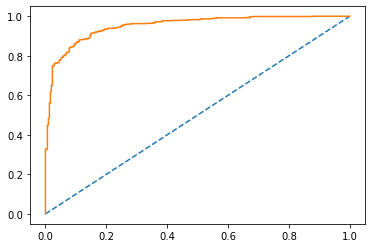

In [186]:
# predict probabilities
probs = grad.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
grad_train_auc = roc_auc_score(y_train, probs)
print('Area under Curve is', grad_train_auc)
# calculate roc curve
grad_train_fpr, grad_train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(grad_train_fpr, grad_train_tpr);

Area under Curve is 0.8993615047779289


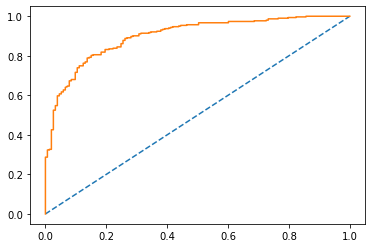

In [187]:
# predict probabilities
probs = grad.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
grad_test_auc = roc_auc_score(y_test, probs)
print('Area under Curve is', grad_test_auc)
# calculate roc curve
grad_test_fpr, grad_test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(grad_test_fpr, grad_test_tpr);

### Insights from our Gradient Boosting Model

#### TRAINING DATA
- Accuracy : 89.25%
- AUC : 95.11%
- Precision : 91%
- Recall : 94%
- F1 score : 93%

#### TEST DATA
- Accuracy : 83.55%
- AUC : 89.93%
- Precision : 85%
- Recall : 91%
- F1 score : 98%

#### OVERALL SUMMARY
-

### Comparison of the performance metrics of all models

In [190]:
index=['Accuracy', 'AUC', 'Recall','Precision','F1 Score']
data = pd.DataFrame({'Logit Train':[LogReg_train__Accuracy,Logreg_train_auc,Logreg_train_recall,Logreg_train_precision,Logreg_train_f1],
        'Logit Test':[LogReg_test_Accuracy,Logreg_test_auc,Logreg_test_recall,Logreg_test_precision,Logreg_test_f1],
       'LDA Train':[LDA_train_accuracy,LDA_train_auc,LDA_train_recall,LDA_train_precision,LDA_train_f1],
        'LDA Test':[LDA_test_Accuracy,LDA_test_auc,LDA_test_recall,LDA_test_precision,LDA_test_f1],
        'KNN Train':[KNN_train_Accuracy,KNN_train_auc,KNN_train_recall,KNN_train_precision,KNN_train_f1],
        'KNN Test':[KNN_test_Accuracy,KNN_test_auc,KNN_test_recall,KNN_test_precision,KNN_test_f1] },index=index)
       
round(data,2)

,Logit Train,Logit Test,LDA Train,LDA Test,KNN Train,KNN Test
Accuracy,0.83,0.83,0.83,0.83,0.85,0.82
AUC,0.89,0.88,0.89,0.89,0.92,0.86
Recall,0.91,0.88,0.91,0.88,0.93,0.91
Precision,0.86,0.86,0.86,0.86,0.87,0.84
F1 Score,0.89,0.87,0.89,0.87,0.90,0.87


In [198]:
index=['Accuracy', 'AUC', 'Recall','Precision','F1 Score']
data = pd.DataFrame({'Naive Bayes Train':[NB_train_Accuracy,NB_train_auc,NB_train_recall,NB_train_precision,NB_train_f1],
        'Naive Bayes Test':[NB_test_Accuracy,NB_test_auc,NB_test_recall,NB_test_precision,NB_test_f1],
       'Bagging Train':[Bag_train_Accuracy,Bag_train_auc,Bag_train_recall,Bag_train_precision,Bag_train_f1],
        'Bagging Test':[Bag_test_Accuracy,Bag_test_auc,Bag_test_recall,Bag_test_precision,Bag_test_f1],
        'Adaboost Train':[Ada_train_Accuracy,Ada_train_auc,Ada_train_recall,Ada_train_precision,Ada_train_f1],
        'Adaboost Test':[Ada_test_Accuracy,Ada_test_auc,Ada_test_recall,Ada_test_precision,Ada_test_f1],
         'Gradient boost Train':[grad_train_Accuracy,grad_train_auc,grad_train_recall,grad_train_precision,grad_train_f1],
        'Gradientboost Test':[grad_test_Accuracy,grad_test_auc,grad_test_recall,grad_test_precision,grad_test_f1]  },index=index)
       
round(data,2)

,Naive Bayes Train,Naive Bayes Test,Bagging Train,Bagging Test,Adaboost Train,Adaboost Test,Gradient boost Train,Gradientboost Test
Accuracy,0.83,0.82,0.84,0.82,0.86,0.81,0.89,0.84
AUC,0.89,0.88,0.91,0.89,0.92,0.88,0.95,0.90
Recall,0.89,0.87,0.94,0.92,0.92,0.89,0.94,0.91
Precision,0.88,0.87,0.85,0.82,0.89,0.84,0.91,0.85
F1 Score,0.88,0.87,0.89,0.87,0.90,0.86,0.93,0.88


#### ROC Curve for all models on the Training data

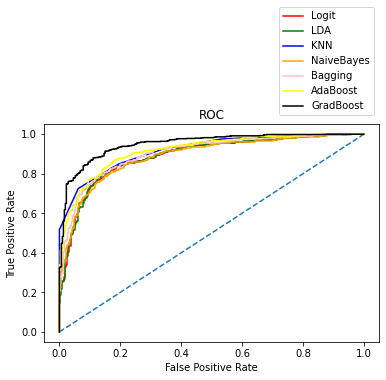

In [199]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(Logit_train_fpr, Logit_train_tpr,color='red',label="Logit")
plt.plot(LDA_train_fpr,LDA_train_tpr,color='green',label="LDA")
plt.plot(KNN_train_fpr,KNN_train_tpr,color='blue',label="KNN")
plt.plot(NB_train_fpr,NB_train_tpr,color='orange',label="NaiveBayes")
plt.plot(Bag_train_fpr,Bag_train_tpr,color='pink',label="Bagging")
plt.plot(Ada_train_fpr,Ada_train_tpr,color='yellow',label="AdaBoost")
plt.plot(grad_train_fpr,grad_train_tpr,color='black',label="GradBoost")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower right')

#### ROC Curve for all models on the Test data

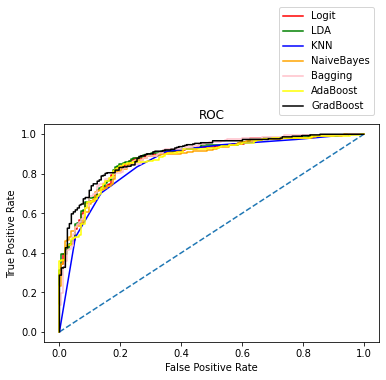

In [200]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(Logit_test_fpr, Logit_test_tpr,color='red',label="Logit")
plt.plot(LDA_test_fpr,LDA_test_tpr,color='green',label="LDA")
plt.plot(KNN_test_fpr,KNN_test_tpr,color='blue',label="KNN")
plt.plot(NB_test_fpr,NB_test_tpr,color='orange',label="NaiveBayes")
plt.plot(Bag_test_fpr,Bag_test_tpr,color='pink',label="Bagging")
plt.plot(Ada_test_fpr,Ada_test_tpr,color='yellow',label="AdaBoost")
plt.plot(grad_test_fpr,grad_test_tpr,color='black',label="GradBoost")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower right')

<div class="alert alert-block alert-info">
    
### C) Inference:

### Q 1.8 Based on these predictions, what are the insights? (5 marks)

- Refer to Business Report

# Problem 2

In this particular project, we are going to work on the inaugural corpora from the nltk in Python. We will be looking at the following speeches of the Presidents of the United States of America:

1. President Franklin D. Roosevelt in 1941
2. President John F. Kennedy in 1961
3. President Richard Nixon in 1973

(Hint: use .words(), .raw(), .sent() for extracting counts)

### Data Description:


### Attribute Information: 
Data Dictionary:

### Q 2.1 Find the number of characters, words, and sentences for the mentioned documents. 

In [ ]:
# Importing required packages


import re # this is the regular expression library which helps us manipulate text (strings) fairly easily and intuitively
import nltk # this is the Natural Language Tool Kit which contains a lot of functionalities for text analytics
from warnings import filterwarnings
filterwarnings("ignore")

### Checking the US Presdidential Speech

In [ ]:
## Importing the inaugural speeches
nltk.download('inaugural')
from nltk.corpus import inaugural
inaugural.fileids()

### 1. Speech of President Franklin D. Roosevelt in 1941

In [ ]:
## Reading the Speech Text of President Franklin D. Roosevelt in 1941
print(inaugural.raw("1941-Roosevelt.txt"))

In [ ]:
## Reading the first 20 words in speech
print(inaugural.words("1941-Roosevelt.txt")[:20])

In [ ]:
## Reading the First 5 sentences in speech
print(inaugural.sents("1941-Roosevelt.txt")[:5])

In [ ]:
## Reading the last line in the speech
print(inaugural.sents("1941-Roosevelt.txt")[-1])

#### Basic information about the President Franklin D. Roosevelt 1941 speech

In [ ]:
num_chars_Rv = len(inaugural.raw("1941-Roosevelt.txt"))
num_words_Rv = len(inaugural.words("1941-Roosevelt.txt"))
num_sents_Rv = len(inaugural.sents("1941-Roosevelt.txt"))

print(" The numbers of characters in Roosevelt 1941 speech is:",num_chars_Rv)
print(" The numbers of words in Roosevelt 1941 speech is:",num_words_Rv)
print(" The numbers of sentences in Roosevelt 1941 speech is:",num_sents_Rv)

### 2. Speech of President John F. Kennedy in 1961

In [ ]:
## Reading the Speech Text of President John F. Kennedy in 1961
print(inaugural.raw("1961-Kennedy.txt"))

In [ ]:
## Reading the first 20 words in speech
print(inaugural.words("1961-Kennedy.txt")[:20])

In [ ]:
## Reading the First 5 sentences in speech
print(inaugural.sents("1961-Kennedy.txt")[:5])

In [ ]:
## Reading the last line in the speech
print(inaugural.sents("1961-Kennedy.txt")[-1])

#### Basic information about the President John F. Kennedy 1961 speech

In [ ]:
num_chars_Ken = len(inaugural.raw("1961-Kennedy.txt"))
num_words_Ken = len(inaugural.words("1961-Kennedy.txt"))
num_sents_Ken = len(inaugural.sents("1961-Kennedy.txt"))

print(" The numbers of characters in Kennedy 1961 speech is:",num_chars_Ken)
print(" The numbers of words in Kennedy 1961 speech is:",num_words_Ken)
print(" The numbers of sentences in Kennedy 1961 speech is:",num_sents_Ken)

### 3. Speech of President Richard Nixon in 1973

In [ ]:
## Reading the Speech Text of President Richard Nixon in 1973
print(inaugural.raw("1973-Nixon.txt"))

In [ ]:
## Reading the first 20 words in speech
print(inaugural.words("1973-Nixon.txt")[:20])

In [ ]:
## Reading the First 5 sentences in speech
print(inaugural.sents("1973-Nixon.txt")[:5])

In [ ]:
## Reading the last line in the speech
print(inaugural.sents("1973-Nixon.txt")[-1])

#### Basic information about the Richard Nixon 1973 speech

In [ ]:
num_chars_Nix = len(inaugural.raw("1973-Nixon.txt"))
num_words_Nix = len(inaugural.words("1973-Nixon.txt"))
num_sents_Nix = len(inaugural.sents("1973-Nixon.txt"))

print(" The numbers of characters in Nixon 1973 speech is:",num_chars_Nix)
print(" The numbers of words in Nixon 1973 speech is:",num_words_Nix)
print(" The numbers of sentences in Nixon 1973 speech is:",num_sents_Nix)

### Q 2.2 Remove all the stopwords from all three speeches. 

### 1.  Cleaning the President Roosevelt 1941 Speech document

In [ ]:
## Converting to Lower Case
raw_Rv = inaugural.raw("1941-Roosevelt.txt").lower()
raw_Rv

In [ ]:
## Cleaning the special characters (/@$: etc)

raw_Rv = re.sub("[^a-zA-Z]"," ",str(raw_Rv))

In [ ]:
raw_Rv

In [ ]:
## Tokenization -  Splitting the text files into words
tokens_Rv = nltk.word_tokenize(raw_Rv)
print(tokens_Rv)

In [ ]:
## Stop words -  Removing words that are not useful or Removing meaningless words 
from nltk.corpus import stopwords
en_stop = stopwords.words('english')
stopped_tokens_Rv = [i for i in tokens_Rv if not i in en_stop]

In [ ]:
stopped_tokens_Rv

In [ ]:
## Stemming Using Lemmatizer -  Stem the words to its root word
from nltk import WordNetLemmatizer
lt = nltk.WordNetLemmatizer()
texts_Rv = [lt.lemmatize(i) for i in stopped_tokens_Rv]

In [ ]:
texts_Rv

In [ ]:
## Top 15 frequency occuring words
Rv_15 = nltk.FreqDist(texts_Rv).most_common(15)
Rv_15

- Here, we see words like know and u are coming frequently but adds no value to our document. Therefore, they need to be considered as a Stop Word

In [ ]:
stop_Rv = stopwords.words("english")

In [ ]:
#adding words in stop words
stop_Rv.append("know")
stop_Rv.append("u")

In [ ]:
Cleaned_Rv = [i for i in texts_Rv if not i in stop_Rv]

In [ ]:
RV_15=nltk.FreqDist(Cleaned_Rv).most_common(15)
RV_15

### 2.  Cleaning the President John F. Kennedy 1961 Speech document

In [ ]:
## Converting to Lower Case
raw_Ken = inaugural.raw("1961-Kennedy.txt").lower()
raw_Ken

In [ ]:
## Cleaning the special characters (/@$: etc)

raw_Ken = re.sub("[^a-zA-Z]"," ",str(raw_Ken))

In [ ]:
raw_Ken

In [ ]:
## Tokenization -  Splitting the text files into words
tokens_Ken = nltk.word_tokenize(raw_Ken)
print(tokens_Ken)

In [ ]:
## Stop words -  Removing words that are not useful or Removing meaningless words 
from nltk.corpus import stopwords
en_stop = stopwords.words('english')
stopped_tokens_Ken = [i for i in tokens_Ken if not i in en_stop]

In [ ]:
stopped_tokens_Ken

In [ ]:
## Stemming Using Lemmatizer -  Stem the words to its root word
from nltk import WordNetLemmatizer
lt = nltk.WordNetLemmatizer()
texts_Ken = [lt.lemmatize(i) for i in stopped_tokens_Ken]

In [ ]:
texts_Ken

In [ ]:
## Top 15 frequency occuring words
Ken_15 = nltk.FreqDist(texts_Ken).most_common(15)
Ken_15

- Here, we see words like let and u are coming frequently but adds no value to our document. Therefore, they need to be considered as a Stop Word

In [ ]:
stop_Ken = stopwords.words("english")

In [ ]:
#adding words in stop words
stop_Ken.append("let")
stop_Ken.append("u")

In [ ]:
Cleaned_Ken = [i for i in texts_Ken if not i in stop_Ken]

In [ ]:
KEN_15=nltk.FreqDist(Cleaned_Ken).most_common(15)
KEN_15

### 3.  Cleaning the President Richard Nixon 1973 Speech document

In [ ]:
## Converting to Lower Case
raw_Nix = inaugural.raw("1973-Nixon.txt").lower()
raw_Nix

In [ ]:
## Cleaning the special characters (/@$: etc)

raw_Nix = re.sub("[^a-zA-Z]"," ",str(raw_Nix))

In [ ]:
raw_Nix

In [ ]:
## Tokenization -  Splitting the text files into words
tokens_Nix = nltk.word_tokenize(raw_Nix)
print(tokens_Nix)

In [ ]:
## Stop words -  Removing words that are not useful or Removing meaningless words 
from nltk.corpus import stopwords
en_stop = stopwords.words('english')
stopped_tokens_Nix = [i for i in tokens_Nix if not i in en_stop]

In [ ]:
stopped_tokens_Nix

In [ ]:
## Stemming Using Lemmatizer -  Stem the words to its root word
from nltk import WordNetLemmatizer
lt = nltk.WordNetLemmatizer()
texts_Nix = [lt.lemmatize(i) for i in stopped_tokens_Nix]

In [ ]:
texts_Nix

In [ ]:
## Top 15 frequency occuring words
Nix_15 = nltk.FreqDist(texts_Nix).most_common(15)
Nix_15

In [ ]:
stop_Nix = stopwords.words("english")

In [ ]:
#adding words in stop words
stop_Nix.append("let")
stop_Nix.append("u")

In [ ]:
Cleaned_Nix = [i for i in texts_Nix if not i in stop_Nix]

In [ ]:
NIX_15=nltk.FreqDist(Cleaned_Nix).most_common(15)
NIX_15

### Q 2.3 Which word occurs the most number of times in his inaugural address for each president? Mention the top three words. (after removing the stopwords) 

### 1. Word Analysis for President Roosevelt 1941 Speech

In [ ]:
## Top 03 frequently occuring words
RV_3 =nltk.FreqDist(Cleaned_Rv).most_common(3)
RV_3

In [ ]:
## Plotting the top 30 words occuring frequently
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
nltk.FreqDist(Cleaned_Rv).plot(30);

In [ ]:
# Dispersion Plot
# Lexical dispersion is a measure of how frequently a word appears across the parts of a corpus.

from nltk.draw.dispersion import dispersion_plot
plt.figure(figsize=(8, 6))
words_used=["nation","life","people"]
dispersion_plot(Cleaned_Rv, words_used, ignore_case=True, title='Dispersion Plot')

### 2. Word Analysis for President John F. Kennedy 1961 Speech

In [ ]:
## Top 03 frequently occuring words
KEN_3 =nltk.FreqDist(Cleaned_Ken).most_common(3)
KEN_3

In [ ]:
## Plotting the top 30 words occuring frequently

plt.figure(figsize=(8, 6))
nltk.FreqDist(Cleaned_Ken).plot(30);

In [ ]:
# Dispersion Plot

plt.figure(figsize=(8, 6))
words_used=["world","side","power"]
dispersion_plot(Cleaned_Ken, words_used, ignore_case=True, title='Dispersion Plot')

### 3. Word Analysis for President Richard Nixon 1973 Speech

In [ ]:
## Top 03 frequently occuring words
NIX_3 =nltk.FreqDist(Cleaned_Nix).most_common(3)
NIX_3

In [ ]:
## Plotting the top 30 words occuring frequently

plt.figure(figsize=(8, 6))
nltk.FreqDist(Cleaned_Nix).plot(30);

In [ ]:
# Dispersion Plot

plt.figure(figsize=(8, 6))
words_used=["america","peace","world"]
dispersion_plot(Cleaned_Nix, words_used, ignore_case=True, title='Dispersion Plot')

### Q 2.4 Plot the word cloud of each of the speeches of the variable. (after removing the stopwords) 

### 1. Wordcloud for President Roosevelt 1941 Speech

In [ ]:
## Creating WordCloud
from wordcloud import WordCloud , STOPWORDS 

plt.subplots(figsize=(10,10))
wordcloud = WordCloud(background_color='white',max_words=50,
                            width=1200,height=1000).generate(" ".join(Cleaned_Rv))

plt.title("MOST USED WORDS",fontsize=20)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 2. Wordcloud for President John F. Kennedy 1961 Speech

In [ ]:
## Creating WordCloud

plt.subplots(figsize=(10,10))
wordcloud = WordCloud(background_color='white',max_words=50,
                            width=1200,height=1000).generate(" ".join(Cleaned_Ken))

plt.title("MOST USED WORDS",fontsize=20)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 3. Wordcloud for President Richard Nixon 1973 Speech

In [ ]:
## Creating WordCloud

plt.subplots(figsize=(10,10))
wordcloud = WordCloud(background_color='white',max_words=50,
                            width=1200,height=1000).generate(" ".join(Cleaned_Nix))

plt.title("MOST USED WORDS",fontsize=20)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## END